In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sqlalchemy
%matplotlib inline
%load_ext sql

source: usgs,prism,calfire

### to do
ratio part, \
adding vertical bars, \
taking average for all three times zone and \
having different colors representing different fires

### get discharge by month

In [2]:
#***logic: precipitation influences discharge***

flow=pd.read_csv('usgs discharge.csv')#usgs discharge
#flow=flow[flow['year']>=1991]
#flow=flow[flow['year']<2021].reset_index().drop(columns=['index'])
#df.index = df.index + 1
display(flow)
flow[flow['year']==1997]

,year,month,ave_discharge
0,1907,10,67.00
1,1907,11,76.70
2,1907,12,195.30
3,1908,1,448.70
4,1908,2,291.80
...,...,...,...
1363,2021,5,80.70
1364,2021,6,18.00
1365,2021,7,2.59
1366,2021,8,0.00


,year,month,ave_discharge
1071,1997,1,7129.0
1072,1997,2,1285.0
1073,1997,3,573.6
1074,1997,4,419.2
1075,1997,5,243.7
1076,1997,6,113.1
1077,1997,7,51.5
1078,1997,8,30.1
1079,1997,9,22.5
1080,1997,10,45.4


### get prec by month

In [3]:
prec0=pd.read_csv('189501_198012.csv').drop(columns=['Unnamed: 0'])
prec0=prec0.round(decimals = 2)
prec0

,year,month,min,max,mean,median,std
0,1895,1,242.89,771.19,484.67,475.53,146.70
1,1895,2,59.51,147.20,110.90,111.22,25.87
2,1895,3,58.88,182.75,114.81,113.98,32.31
3,1895,4,45.41,138.68,83.90,82.96,22.09
4,1895,5,36.47,194.62,100.07,92.57,44.79
...,...,...,...,...,...,...,...
1027,1980,8,0.00,6.39,0.63,0.00,1.30
1028,1980,9,0.00,17.30,2.06,0.00,4.07
1029,1980,10,3.54,39.51,23.42,22.43,9.89
1030,1980,11,5.59,42.93,26.07,28.89,9.12


In [4]:
#prism precipition by months from 1981/1-2021/11
#(there are maximum 82 sources collected by each month range from 1 to 82 indicated by val of variety col)
prec=pd.read_csv('combine.csv').drop(columns=['fid','DN','_minority','_majority']).rename(columns={'_median':'median','_max':'max','_min':'min','_range':'range(max-min)',"_sum": "sum",'_mean': 'mean','_stdev': 'std','_variety': 'variety','_variance': 'variance'})#prism precipitation
prec['month']=prec['month'].str.extract('(\d+)\.?').astype(int)
prec['variance']=prec['std']**2
prec=prec.sort_values(by=['year','month'])
prec=prec.round(decimals = 2)
prec=prec.iloc[:, [0,1,3,4,5,6,7]]
prec=prec[['year','month','min','max','mean','median','std']]
prec=pd.concat([prec0, prec])
prec

prec=prec[prec['year']>=1907].reset_index().drop(columns=['index'])
prec
#prec=flow[flow['year']<2021].reset_index().drop(columns=['index'])

,year,month,min,max,mean,median,std
0,1907,1,122.72,348.32,220.17,228.41,69.16
1,1907,2,103.28,255.84,199.81,204.14,39.89
2,1907,3,279.49,803.60,530.31,531.01,137.24
3,1907,4,15.45,93.47,48.89,49.35,20.05
4,1907,5,7.77,70.26,32.81,31.74,19.01
...,...,...,...,...,...,...,...
1374,2021,7,0.00,5.79,0.85,0.00,1.71
1375,2021,8,48.14,134.56,98.11,105.40,23.20
1376,2021,9,2.44,11.79,9.09,9.50,1.92
1377,2021,10,183.74,362.47,281.22,285.07,45.77


### merge precipitation dataset with discharge

In [5]:
#merge tbl
#precr=prec.loc[:490]
prec=prec.merge(flow,on=['year','month']).rename(columns={'ave_discharge':'discharge'})
prec

,year,month,min,max,mean,median,std,discharge
0,1907,10,14.22,37.86,25.53,25.86,6.95,67.00
1,1907,11,2.39,11.27,6.39,6.56,1.74,76.70
2,1907,12,109.85,312.20,206.19,202.43,53.86,195.30
3,1908,1,106.32,173.70,132.90,130.96,16.83,448.70
4,1908,2,62.35,108.53,84.52,83.22,12.14,291.80
...,...,...,...,...,...,...,...,...
1363,2021,5,2.44,11.79,9.09,9.50,1.92,80.70
1364,2021,6,0.00,3.21,0.28,0.00,0.73,18.00
1365,2021,7,0.00,5.79,0.85,0.00,1.71,2.59
1366,2021,8,48.14,134.56,98.11,105.40,23.20,0.00


In [6]:
test=prec.head(12)
np.mean(test['discharge'])

198.21108333333336

### conversion to water month year (value mapping alogrithm)

1.m <=9\
y/m->y/m+3\
2.m>=10\
y/m->y+1/m+3

In [7]:
###get water month
prec['month']=prec['month'].astype(str)
precw=prec.copy()
orginm=prec['month']
orginy=prec['year']
factor_dict= {'month':{'10':1 ,'11':2,'12':3,'1': 4,'2':5,'3': 6,'4':7,'5':8,'6':9,'7':10,'8':11,'9':12}}
#precdfix=prec.copy()
precw.replace(factor_dict, inplace=True)
#precfix
precw=precw.rename(columns={'month':'water month'})
precw['month']=orginm.astype(int)
precw

,year,water month,min,max,mean,median,std,discharge,month
0,1907,1,14.22,37.86,25.53,25.86,6.95,67.00,10
1,1907,2,2.39,11.27,6.39,6.56,1.74,76.70,11
2,1907,3,109.85,312.20,206.19,202.43,53.86,195.30,12
3,1908,4,106.32,173.70,132.90,130.96,16.83,448.70,1
4,1908,5,62.35,108.53,84.52,83.22,12.14,291.80,2
...,...,...,...,...,...,...,...,...,...
1363,2021,8,2.44,11.79,9.09,9.50,1.92,80.70,5
1364,2021,9,0.00,3.21,0.28,0.00,0.73,18.00,6
1365,2021,10,0.00,5.79,0.85,0.00,1.71,2.59,7
1366,2021,11,48.14,134.56,98.11,105.40,23.20,0.00,8


In [8]:
###get water year
for row in precw.itertuples():
    if precw.at[row.Index, "month"] >=10:
        precw.at[row.Index, "year"] = precw.at[row.Index, "year"]+1
precw=precw.rename(columns={'year':'water year'})
precw['year']=orginy
precw   

,water year,water month,min,max,mean,median,std,discharge,month,year
0,1908,1,14.22,37.86,25.53,25.86,6.95,67.00,10,1907
1,1908,2,2.39,11.27,6.39,6.56,1.74,76.70,11,1907
2,1908,3,109.85,312.20,206.19,202.43,53.86,195.30,12,1907
3,1908,4,106.32,173.70,132.90,130.96,16.83,448.70,1,1908
4,1908,5,62.35,108.53,84.52,83.22,12.14,291.80,2,1908
...,...,...,...,...,...,...,...,...,...,...
1363,2021,8,2.44,11.79,9.09,9.50,1.92,80.70,5,2021
1364,2021,9,0.00,3.21,0.28,0.00,0.73,18.00,6,2021
1365,2021,10,0.00,5.79,0.85,0.00,1.71,2.59,7,2021
1366,2021,11,48.14,134.56,98.11,105.40,23.20,0.00,8,2021


In [9]:
precw[precw['water year']==1997]

,water year,water month,min,max,mean,median,std,discharge,month,year
1068,1997,1,26.57,102.04,54.48,51.57,19.91,35.0,10,1996
1069,1997,2,80.55,289.38,182.20,176.18,46.18,188.4,11,1996
1070,1997,3,222.97,742.32,493.27,487.52,121.38,2599.0,12,1996
1071,1997,4,242.31,725.73,468.33,466.23,144.02,7129.0,1,1997
1072,1997,5,10.71,35.19,29.01,30.82,5.84,1285.0,2,1997
1073,1997,6,5.10,35.76,17.31,16.82,7.55,573.6,3,1997
1074,1997,7,17.14,54.27,38.25,38.64,7.84,419.2,4,1997
1075,1997,8,3.80,45.18,19.02,20.98,10.84,243.7,5,1997
1076,1997,9,11.79,62.90,33.83,28.19,18.53,113.1,6,1997
1077,1997,10,0.00,8.59,1.17,0.22,1.76,51.5,7,1997


In [10]:
col = precw.pop('month')  
precw.insert(1, 'month', col)
col = precw.pop('year')  
precw.insert(0, 'year', col)
precw=precw.rename(columns={'mean':'precipitation'})#.drop(precw.columns[10], axis=1)
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80
...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00


### adding 8 biggest fire indicator as a feature

In [11]:
#we want to mark all months which are very likely affected by 9 biggest fires
#If the month of the fire is in the first 3 months of the water year, just mark all the months of the water year.
#If the month of the fire is not in the first 3 months of the water year:
#mark all the months of the water year after and including that month
#mark all the months of the following water year
precw['marked']=np.zeros(1368).astype(int)
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,0


### rows looping alogrithm

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
202,1924,1924,8,11,0.00,0.00,0.00,0.00,0.00,0.000,1
203,1924,1924,9,12,0.00,18.65,1.68,0.00,4.08,0.000,1
204,1924,1925,10,1,71.73,194.74,147.68,147.79,32.98,14.200,1
205,1924,1925,11,2,48.00,105.51,75.75,74.25,15.46,88.900,1
206,1924,1925,12,3,114.71,261.38,190.63,190.72,39.75,245.800,1
...,...,...,...,...,...,...,...,...,...,...,...
1293,2015,2015,7,10,0.00,22.86,3.32,2.11,3.94,2.670,1
1294,2015,2015,8,11,0.00,5.34,0.50,0.00,0.98,0.021,1
1295,2015,2015,9,12,0.00,6.27,0.72,0.00,1.30,0.000,1
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.000,1


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1361,2021,2021,3,6,0.00,3.21,0.28,0.00,0.73,245.70,0
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


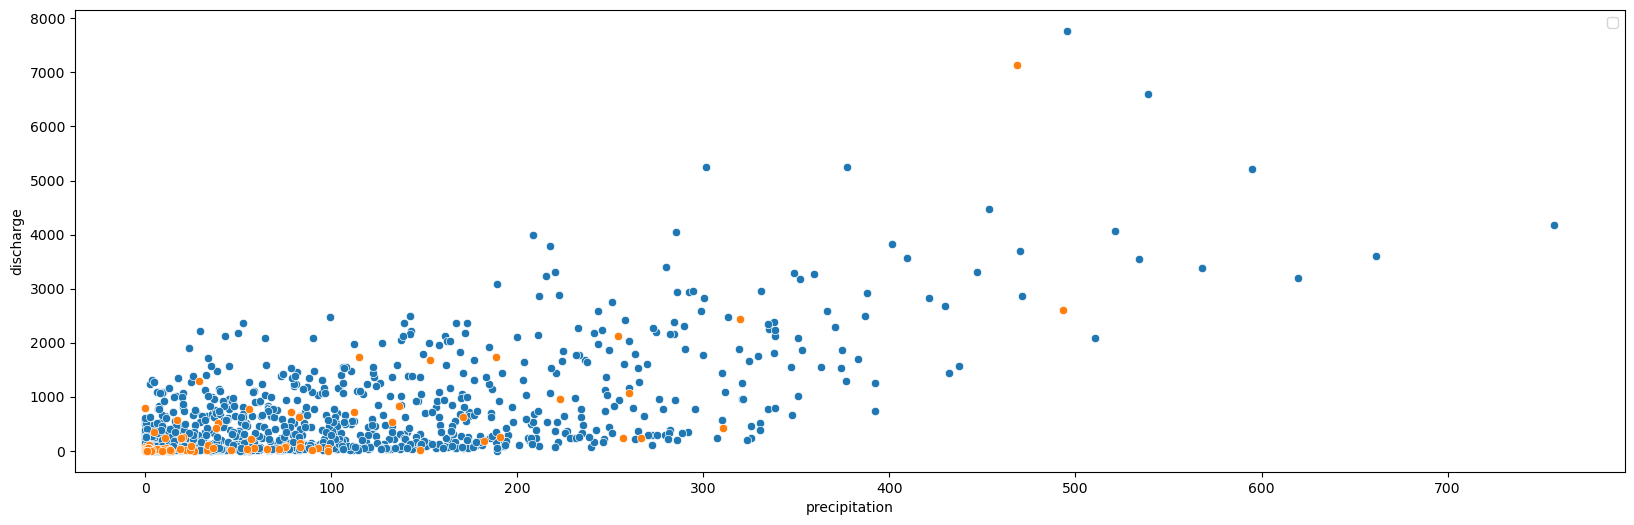

In [12]:
precw['val']=precw['water year']+precw['water month']/100
precw
for row in precw.itertuples():
    if (precw.at[row.Index, "val"] >=1924.11) & (precw.at[row.Index, "val"] <=1925.12) or ((precw.at[row.Index, "val"] >=1952.11) & (precw.at[row.Index, "val"] <=1953.12)) or ((precw.at[row.Index, "val"] >=1973.11) & (precw.at[row.Index, "val"] <=1974.12)) or ((precw.at[row.Index, "val"] >=1976.09) & (precw.at[row.Index, "val"] <=1977.12)) or ((precw.at[row.Index, "val"] >=1996.11) & (precw.at[row.Index, "val"] <=1997.12)) or ((precw.at[row.Index, "val"] >=2014.1) & (precw.at[row.Index, "val"] <=2015.12)) or ((precw.at[row.Index, "val"] >=2021.11) & (precw.at[row.Index, "val"] <=2021.12)):
        precw.at[row.Index, "marked"] = 1
precw=precw.drop(columns=['val'])
display(precw)

precwf=precw[precw['marked']==1]
display(precwf)
precwnf=precw[precw['marked']==0]
display(precwnf)
#sns.scatterplot(data=precw,x="precipition", y="discharge",hue='marked');graph wlo overlay
plt.figure(figsize=(20,6))
#sns.scatterplot(data=precw,x="precipition", y="discharge",hue='marked')
sns.scatterplot(data=precwnf,x="precipitation", y="discharge")
sns.scatterplot(data=precwf,x="precipitation", y="discharge")
plt.legend();

In [13]:
pdsi=pd.read_csv('pdsi.csv').drop(columns=['Unnamed: 0'])
pdsi

,year,water year,month,water month,value
0,1907,1908,10,1,1.670000
1,1907,1908,11,2,-0.933333
2,1907,1908,12,3,-0.513333
3,1908,1908,1,4,-0.780000
4,1908,1908,2,5,-0.700000
...,...,...,...,...,...
1363,2021,2021,5,8,-4.846667
1364,2021,2021,6,9,-5.496667
1365,2021,2021,7,10,-5.906667
1366,2021,2021,8,11,-5.873333


In [14]:
precw['pdsi']=pdsi['value']
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000
...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333


### get ratio
notice the convertion from 

precw['Q/P']=precw['discharge']*0.0283*365*24*60*60/(precw['precipition']*1384527700)

In [15]:
# to get ratio by month we need to determine the day at that month. maybe consider leap year %4==0 &&%100 ！=0 no need consider %400 here
precw['Q/P']=np.ones(1368)
for row in precw.itertuples():
    if (precw.at[row.Index, "month"] ==1) or (precw.at[row.Index, "month"] ==3) or (precw.at[row.Index, "month"] ==5) or (precw.at[row.Index, "month"] ==7) or (precw.at[row.Index, "month"] ==8) or (precw.at[row.Index, "month"] ==10) or (precw.at[row.Index, "month"] ==12):
        precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*31*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)  
    if (precw.at[row.Index, "month"] ==4) or (precw.at[row.Index, "month"] ==6) or (precw.at[row.Index, "month"] ==9) or (precw.at[row.Index, "month"] ==11):
        precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*30*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)
    if (precw.at[row.Index, "month"] ==2):
        if (precw.at[row.Index, "year"] % 4==0) & (precw.at[row.Index, "year"] % 100 !=0):
            precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*28*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)
        else:
            precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*27*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)
        
#precw['Q/P']=precw['discharge']*0.0283*365*24*60*60/(precw['precipition']*1384527700)
precw

/tmp/ipykernel_92/1666403332.py:5: RuntimeWarning: invalid value encountered in double_scalars
  precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*31*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)
/tmp/ipykernel_92/1666403332.py:5: RuntimeWarning: divide by zero encountered in double_scalars
  precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*31*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)
/tmp/ipykernel_92/1666403332.py:7: RuntimeWarning: divide by zero encountered in double_scalars
  precw.at[row.Index, "Q/P"] = precw.at[row.Index, "discharge"]*1000*0.0283*30*24*60*60/(precw.at[row.Index, "precipitation"]*1384527700)


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000


In [16]:
precw.replace([np.inf, -np.inf], 0, inplace=True)

In [17]:
precw['Q/P'] = precw['Q/P'].replace(np.nan, 0)
precw.sort_values(by=['Q/P'])

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P
104,1916,1916,6,9,0.0,0.00,0.00,0.00,0.00,323.30,0,-0.353333,0.000000
1209,2008,2008,7,10,0.0,0.12,0.00,0.00,0.01,15.30,0,-3.866667,0.000000
358,1937,1937,8,11,0.0,0.00,0.00,0.00,0.00,10.90,0,-0.880000,0.000000
120,1917,1918,10,1,0.0,0.00,0.00,0.00,0.00,7.08,0,-1.476667,0.000000
971,1988,1988,9,12,0.0,2.90,0.70,0.42,0.77,0.00,0,-2.050000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
656,1962,1962,6,9,0.0,0.88,0.02,0.00,0.13,155.10,0,-0.823333,410.867307
1328,2018,2018,6,9,0.0,0.38,0.01,0.00,0.04,101.80,0,-1.203333,539.346124
799,1974,1974,5,8,0.0,2.01,0.07,0.00,0.31,792.20,1,-0.446667,619.579473
751,1970,1970,5,8,0.0,0.70,0.02,0.00,0.09,377.00,0,-1.246667,1031.980705


In [18]:
precwf['year'].unique()

array([1924, 1925, 1952, 1953, 1973, 1974, 1976, 1977, 1996, 1997, 2014,
       2015, 2021])

### get relative size based on fire dataset

In [19]:
# we set default val for fire size as the smallest size among 8 major fires for comparison purpose
precw['size']=np.ones(1368)*6.293836e+06
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,6293836.0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,6293836.0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,6293836.0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000,6293836.0


1924, 1925, 1952, 1953, 1973, 1974, 1976, 1977, 1996, 1997, 2014,
       2015, 2021

In [20]:
#there are two major fires on 1924. here we choose to take the sum for the area
for row in precw.itertuples():
    if (precw.at[row.Index, "year"] ==1924) or (precw.at[row.Index, "year"] ==1925):
        precw.at[row.Index, "size"] = 4.440780e+07+3.621041e+07  
    if (precw.at[row.Index, "year"] ==1952) or (precw.at[row.Index, "year"] ==1953):
        precw.at[row.Index, "size"] = 6.293836e+06
    if ((precw.at[row.Index, "year"] ==1973) or (precw.at[row.Index, "year"] ==1974)):
        precw.at[row.Index, "size"] = 4.174565e+07
    if ((precw.at[row.Index, "year"] ==1976) or (precw.at[row.Index, "year"] ==1977)):
        precw.at[row.Index, "size"] = 8.445691e+07
    if ((precw.at[row.Index, "year"] ==1996) or (precw.at[row.Index, "year"] ==1997)):
        precw.at[row.Index, "size"] = 3.572548e+07
    if ((precw.at[row.Index, "year"] ==2014) or (precw.at[row.Index, "year"] ==2015)):
        precw.at[row.Index, "size"] = 1.715572e+07
    if (precw.at[row.Index, "year"] ==2021):
        precw.at[row.Index, "size"] = 8.975377e+08
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000,897537700.0


In [21]:
import plotly.express as px 
#import plotly.graph_objects as go
precww=precw.copy()
precww['marked']=precww['marked'].astype(str)
px.scatter(precww, x="precipitation", y="discharge",color="marked")
#fig = go.Figure()

# Add traces
#fig.add_trace(go.Scatter(x=precwnf['precipition'], y=precwnf['discharge']))
#fig.add_trace(go.Scatter(x=precwf['precipition'], y=precwf['discharge']))
#fig.show()
#px.scatter(precwf, x="precipition", y="discharge")

for row in precw.itertuples():
    if precw.at[row.Index, "month"] >=10:
        precw.at[row.Index, "year"] = precw.at[row.Index, "year"]+1

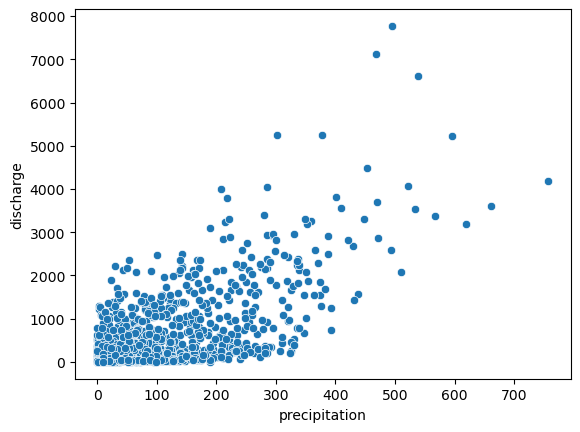

In [22]:
#scatter btw prec& discharge on month scale reg yr
sns.scatterplot(x=prec["mean"], y=prec["discharge"])
plt.xlabel("precipitation");

In [23]:
corr1=prec['mean'].corr(prec['discharge'])
corr1

0.6821059552883103

### getting monthly analysis by making the time alogrithm

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



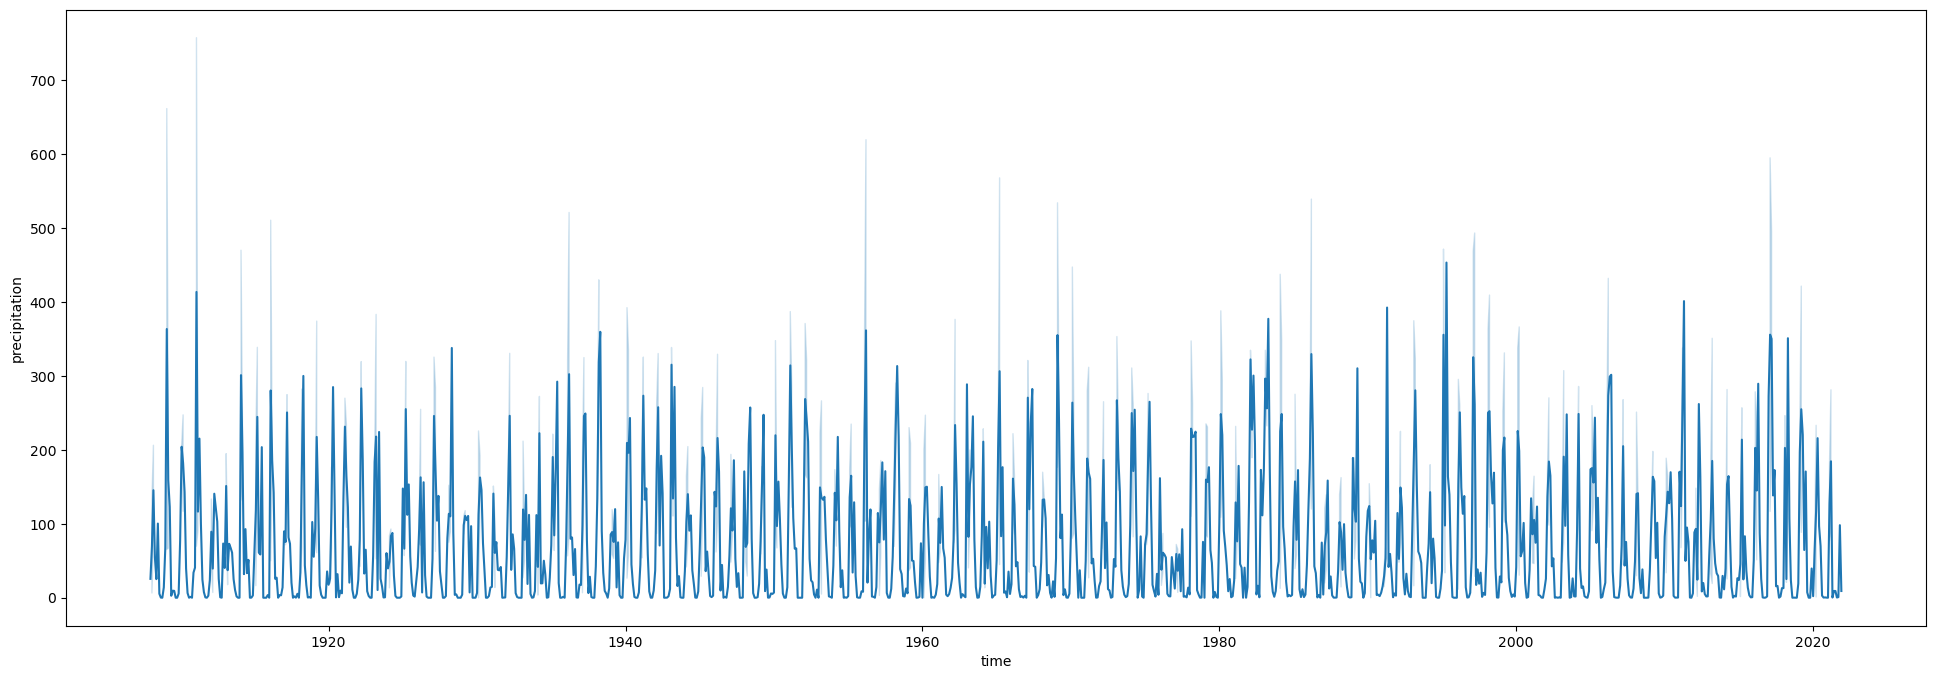

In [24]:
###regular year###
precr=prec.copy()
precr['month']=precr['month'].astype(int)
precr['time']=precr['year']+precr['month']*0.1
precr
plt.figure(figsize=(24,8))
sns.lineplot(precr['time'], precr['mean']);
plt.ylabel("precipitation");
#sns.lineplot(precrr['time'], precrr['discharge'])

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



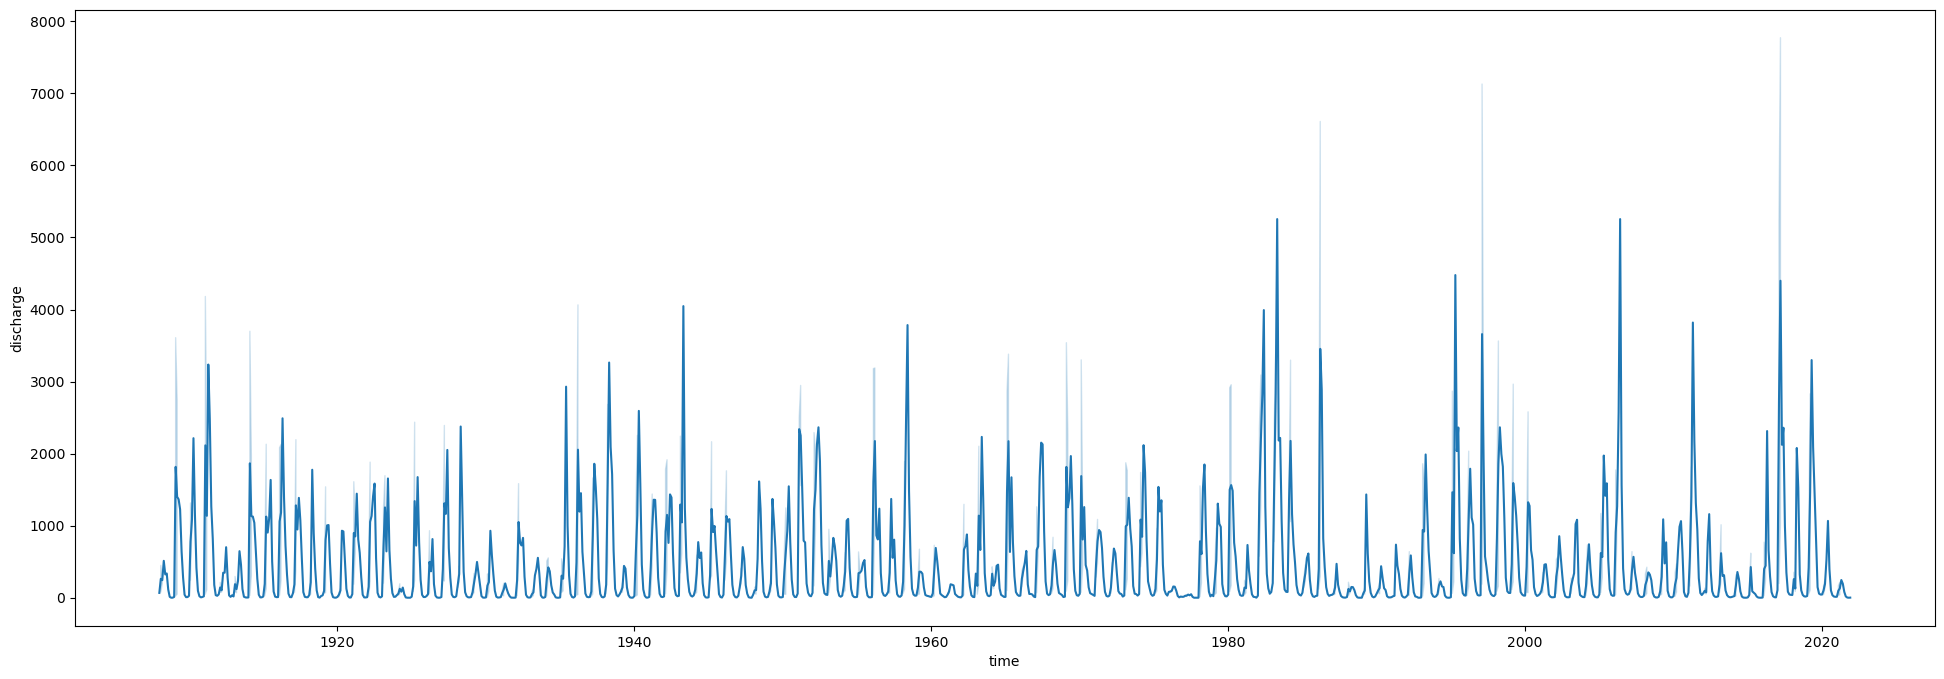

In [25]:
plt.figure(figsize=(24,8))
sns.lineplot(precr['time'], precr['discharge']);

In [26]:
precr=precr.rename(columns={'mean':'precipitation'})

### add subplot for plotly

In [27]:
# import graph_objects from plotly package
import plotly.graph_objects as go
 
# import make_subplots function from plotly.subplots
# to make grid of plots
from plotly.subplots import make_subplots
 
# use specs parameter in make_subplots function
# to create secondary y-axis
fig1 = make_subplots(specs=[[{"secondary_y": True}]])

# plot a scatter chart by specifying the x and y values
# Use add_trace function to specify secondary_y axes.
fig1.add_trace(
    go.Scatter(x=precr['time'], y=precr['precipitation'], name="precipitation"),
    secondary_y=False)
 
# Use add_trace function and specify secondary_y axes = True.
fig1.add_trace(
    go.Scatter(x=precr['time'], y=precr['discharge'], name="discharge"),
    secondary_y=True,)
 
# Adding title text to the figure
fig1.update_layout(
    title_text="relationship between precipition and discharge"
)
 
# Naming x-axis
fig1.update_xaxes(title_text="time")
 
# Naming y-axes
fig1.update_yaxes(title_text="precipitation", secondary_y=False)
fig1.update_yaxes(title_text="discharge", secondary_y=True)


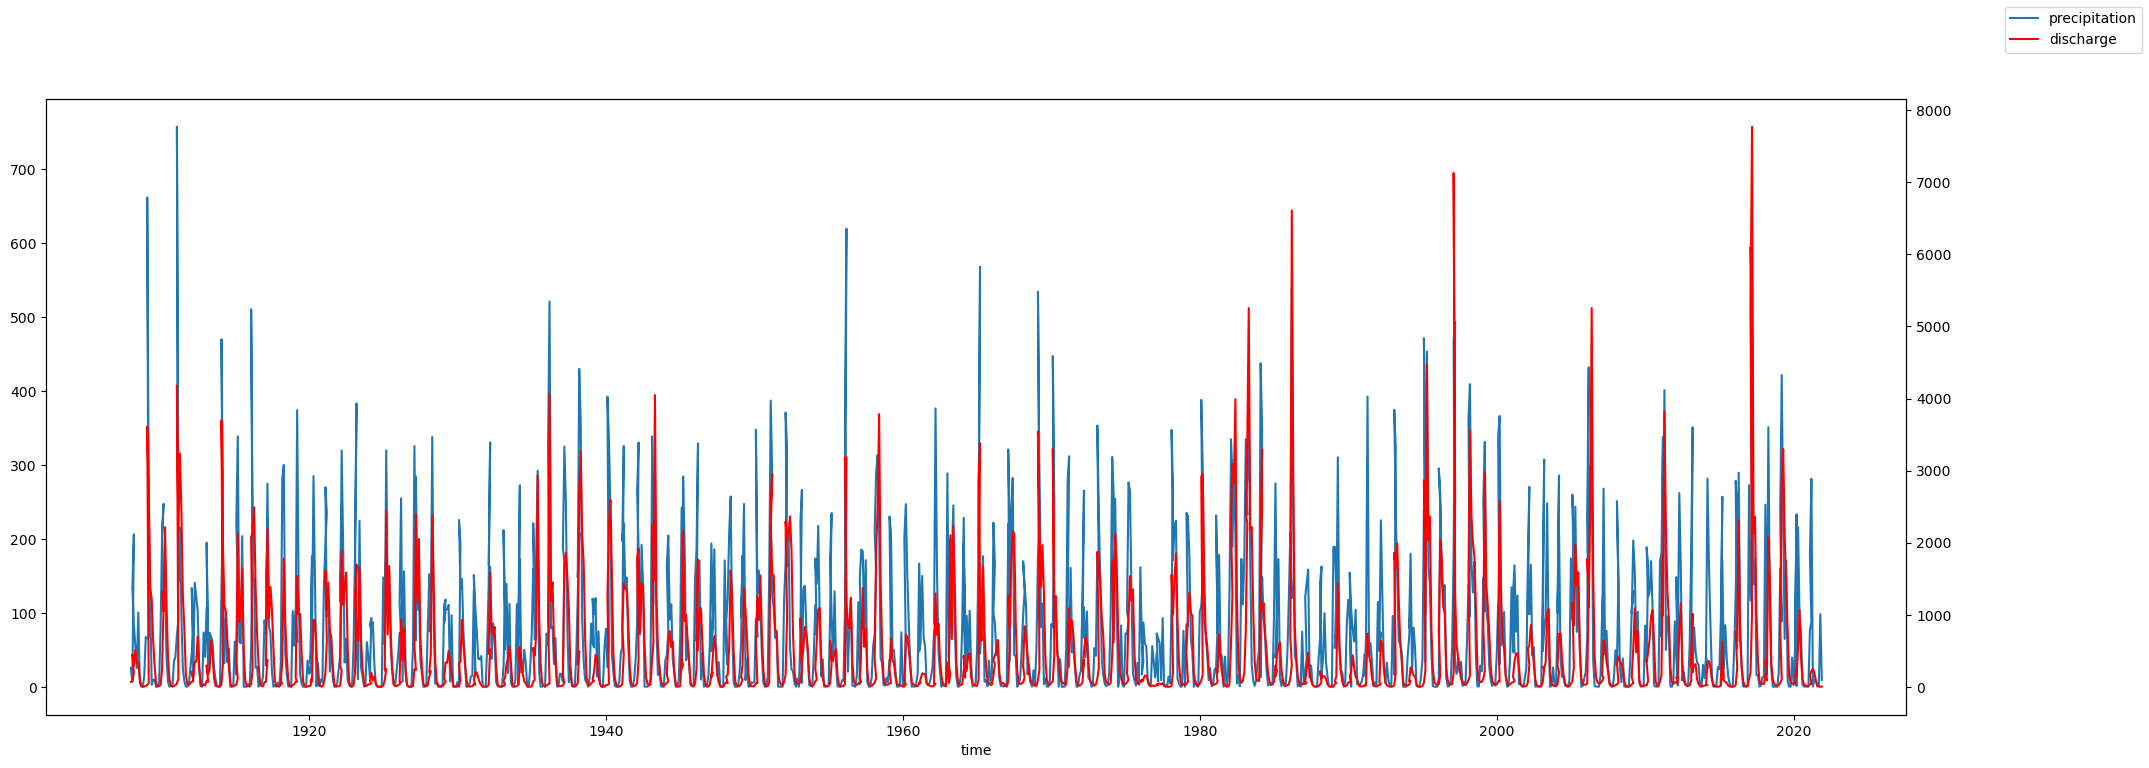

In [28]:
f,ax=plt.subplots(1,1,figsize=(24,8))
precr.plot(x="time", y="precipitation", ax=ax,legend=False)
ax2 = ax.twinx()
precr.plot(x="time", y="discharge", ax=ax2, legend=False, color="r")
ax.figure.legend();

/tmp/ipykernel_92/2035565866.py:2: FutureWarning:

Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.



,year,precipitation,discharge
0,1907,79.370000,113.000000
1,1908,51.348333,176.961083
2,1909,132.690000,944.168333
3,1910,62.050833,537.530833
4,1911,115.838333,1215.141667
...,...,...,...
110,2017,143.949167,1606.450000
111,2018,78.146667,400.183333
112,2019,120.390833,983.191667
113,2020,52.609167,211.025000


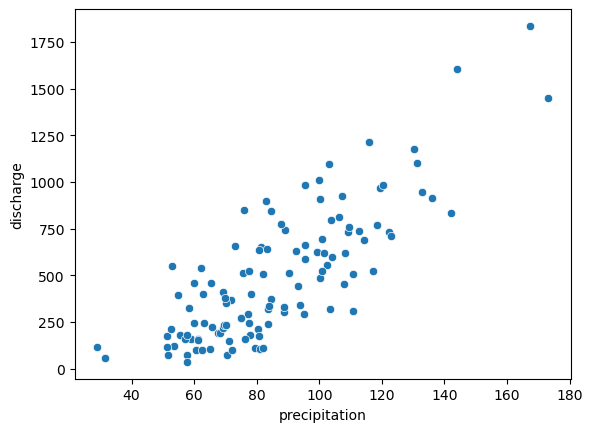

In [29]:
#scatter btw prec& discharge on year scale regular year
precy=prec.groupby('year')['mean','discharge'].mean()
precy=precy.reset_index().rename(columns={'mean':'precipitation'})
display(precy)
sns.scatterplot(x=precy["precipitation"], y=precy["discharge"]);

In [30]:
corr2=precy['precipitation'].corr(precy['discharge'])
corr2

0.8073392897031028

### add subplot for matlibplot with vertical bar for fire years

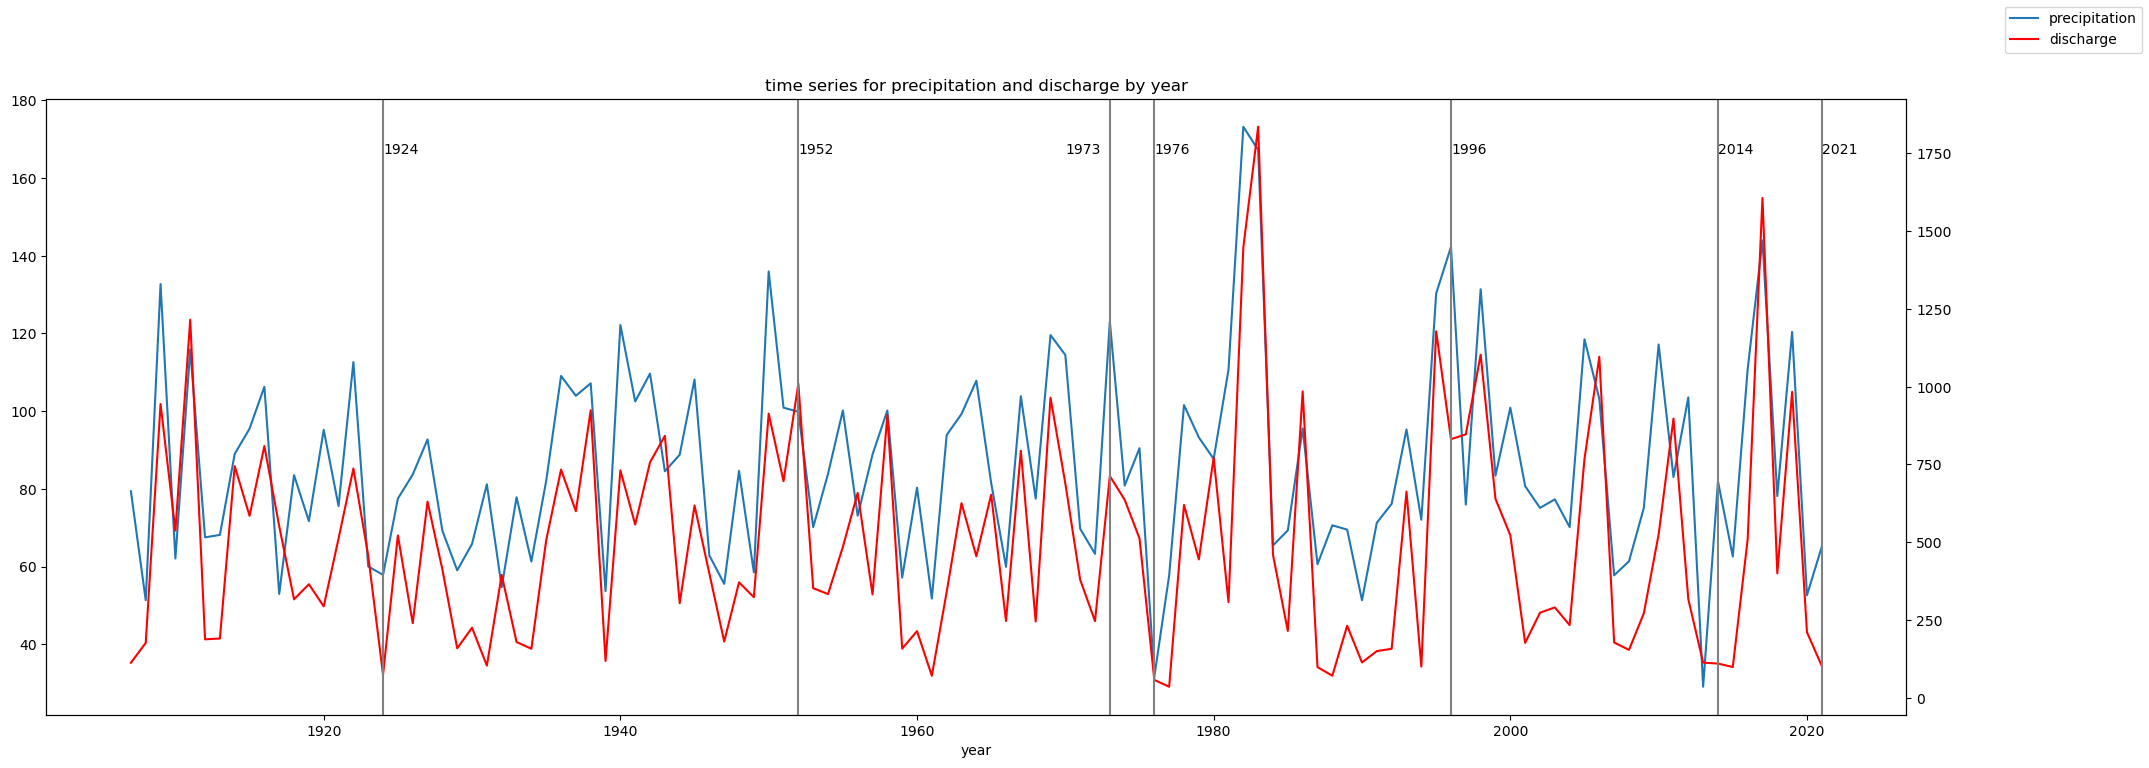

In [31]:
#
f,ax=plt.subplots(1,1,figsize=(24,8))
precy.plot(x="year", y="precipitation", ax=ax,legend=False)
ax2 = ax.twinx()
precy.plot(x="year", y="discharge", ax=ax2, legend=False, color="r")
ax.figure.legend()
plt.axvline(x=1924, color='grey')
plt.axvline(x=1952, color='grey')
plt.axvline(x=1973, color='grey')
plt.axvline(x=1976, color='grey')
plt.axvline(x=1996, color='grey')
plt.axvline(x=2014, color='grey')
plt.axvline(x=2021, color='grey')
plt.annotate('1924', xy=(1924, 160), xytext=(1924, 1750))
plt.annotate('1952', xy=(1952, 160), xytext=(1952,1750))
plt.annotate('1973', xy=(1973, 160), xytext=(1970, 1750))
plt.annotate('1976', xy=(1976, 160), xytext=(1976, 1750))
plt.annotate('1996', xy=(1996, 160), xytext=(1996, 1750))
plt.annotate('2014', xy=(2014, 160), xytext=(2014, 1750))
plt.annotate('2021', xy=(2021, 160), xytext=(2021, 1750))
plt.title('time series for precipitation and discharge by year');

In [32]:
fig2 = make_subplots(specs=[[{"secondary_y": True}]])
fig2.add_trace(
    go.Scatter(x=precy['year'], y=precy['precipitation'], name="precipitation"),
    secondary_y=False)
 
# Use add_trace function and specify secondary_y axes = True.
fig2.add_trace(
    go.Scatter(x=precy['year'], y=precy['discharge'], name="discharge"),
    secondary_y=True,)
 
# Adding title text to the figure
fig2.update_layout(
    title_text="relationship between precipitation and discharge"
)
 
# Naming x-axis
fig2.update_xaxes(title_text="year")
 
# Naming y-axes
fig2.update_yaxes(title_text="precipitation", secondary_y=False)
fig2.update_yaxes(title_text="discharge", secondary_y=True)

In [33]:
precw=precw.rename(columns={'mean':'precipitation'})

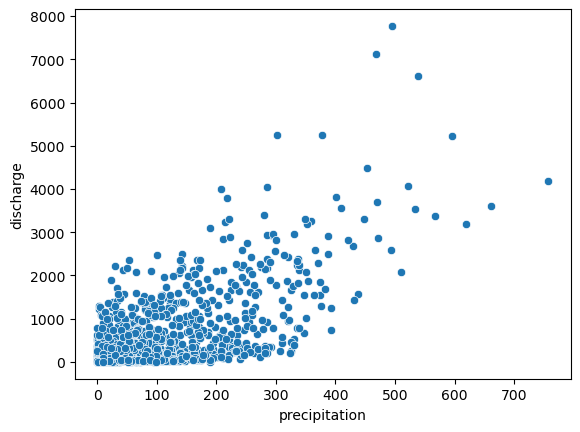

In [34]:
###scatter btw prec& discharge on month scale water yr###

sns.scatterplot(x=precw["precipitation"], y=precw["discharge"]);
#plt.xlabel("precipition");

In [35]:
corr11=precw['precipitation'].corr(precw['discharge'])
corr11

0.6821059552883103

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



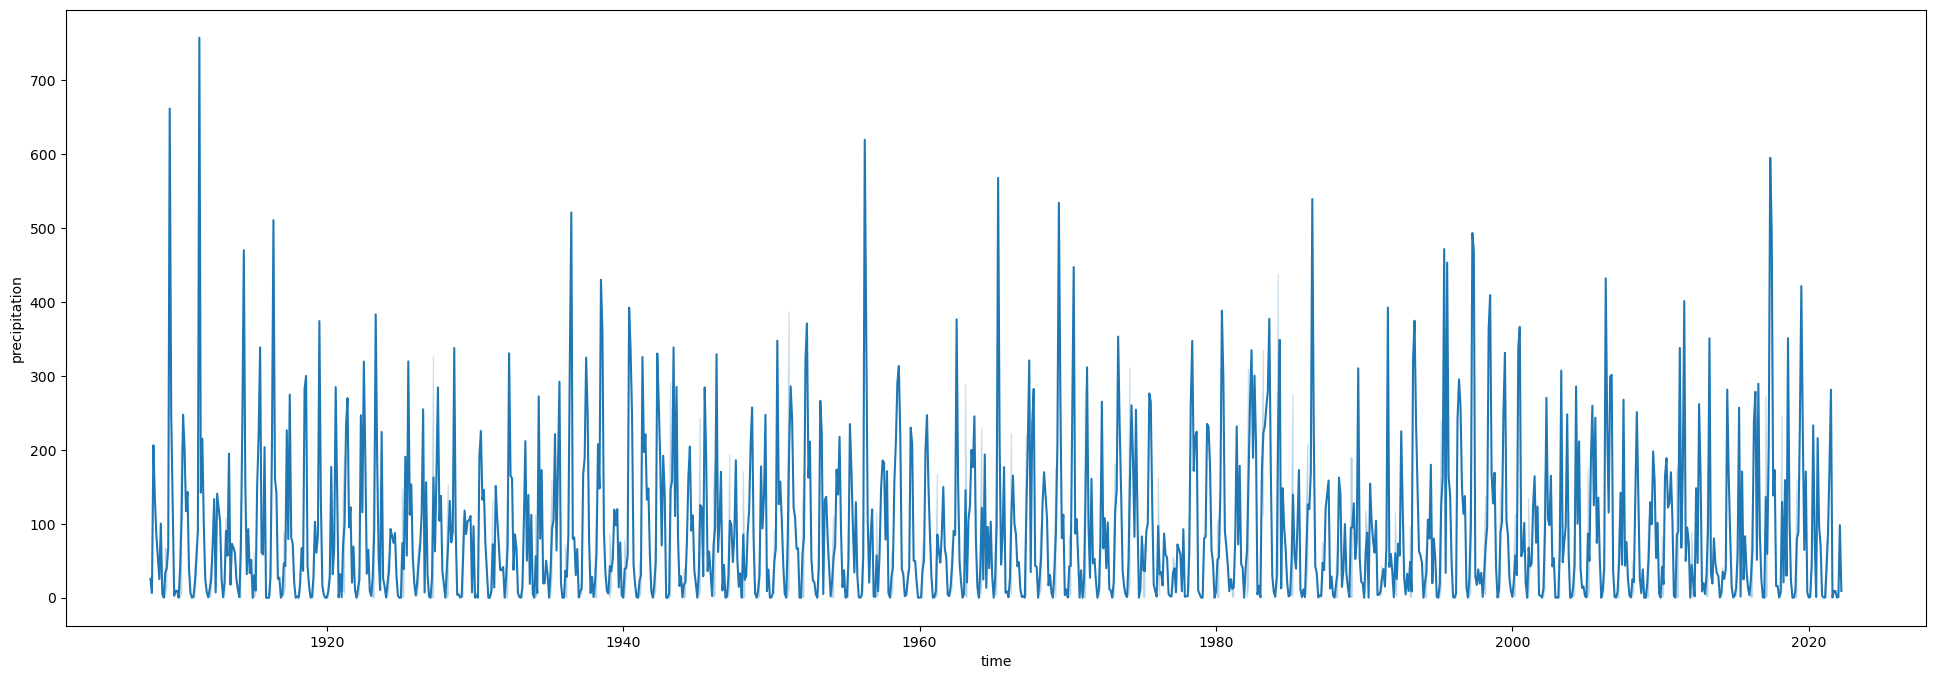

In [36]:
precwr=precw.copy()
precwr['time']=precwr['water year']+precwr['water month']*0.1
precwr
plt.figure(figsize=(24,8))
sns.lineplot(precwr['time'], precwr['precipitation']);
#plt.ylabel("precipition");

/opt/conda/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning:

Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.



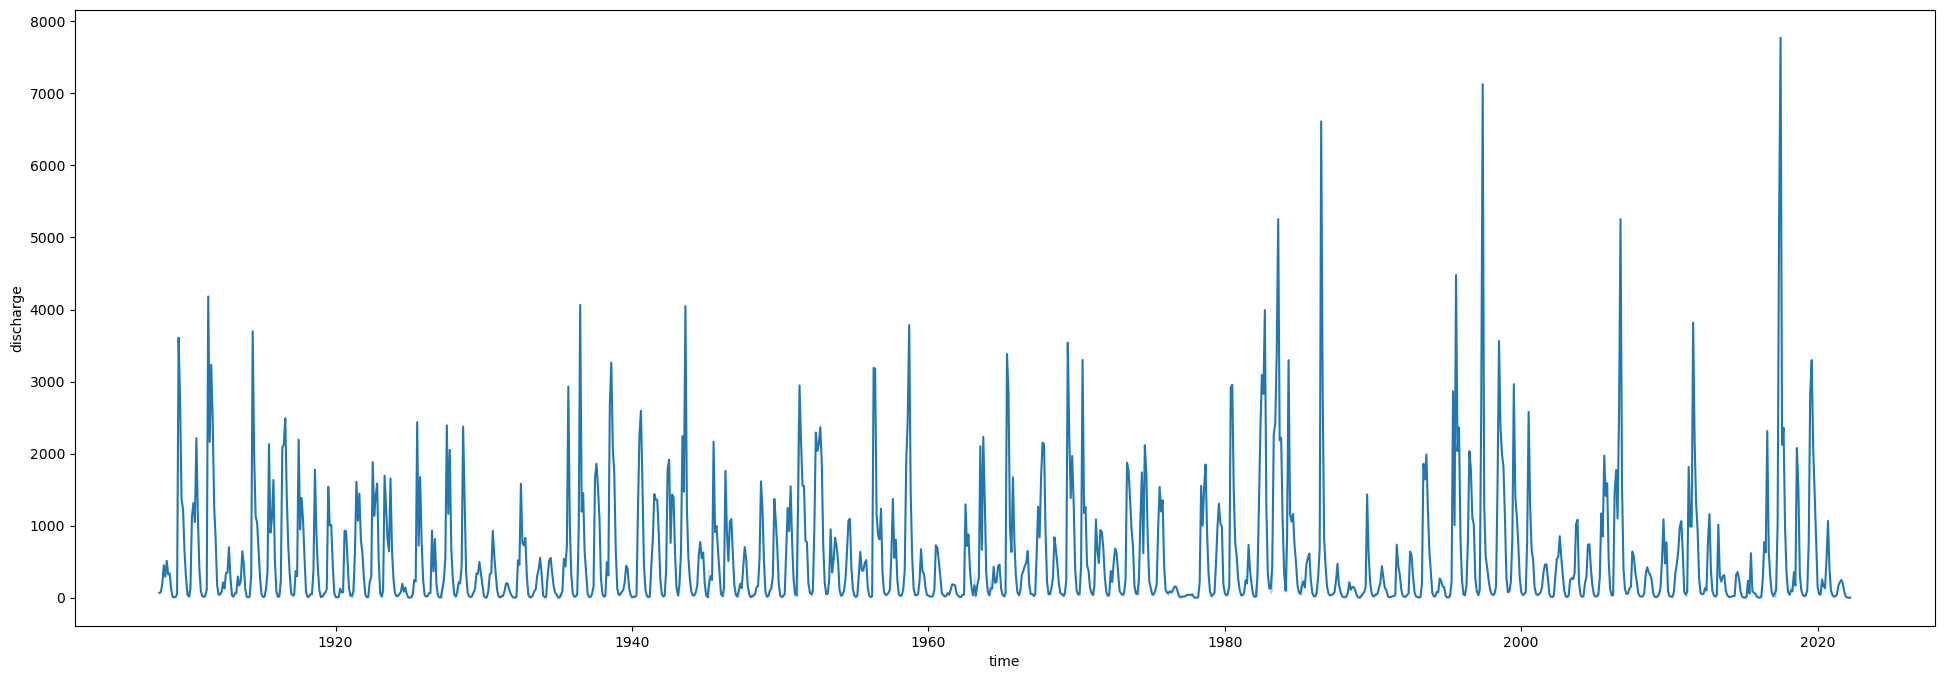

In [37]:
plt.figure(figsize=(24,8))
sns.lineplot(precwr['time'], precwr['discharge']);

In [38]:
precwr=precwr.rename(columns={'mean':'precipitation'})

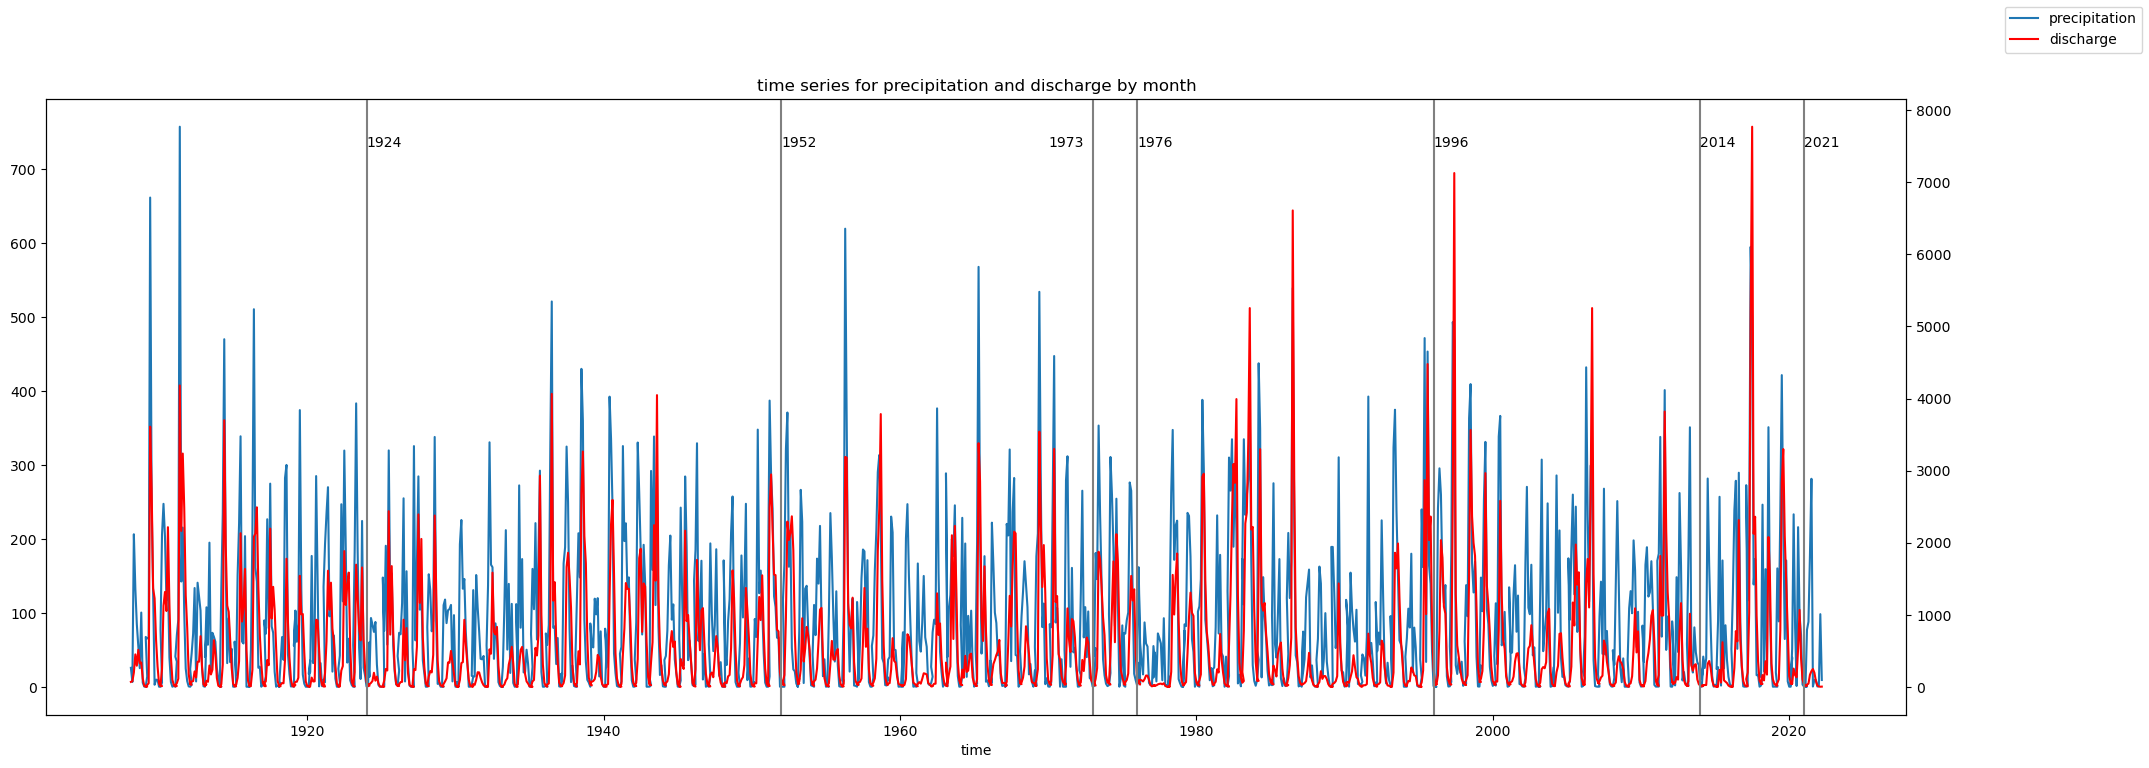

In [39]:
f,ax=plt.subplots(1,1,figsize=(24,8))
precwr.plot(x="time", y="precipitation", ax=ax,legend=False)
ax2 = ax.twinx()
precwr.plot(x="time", y="discharge", ax=ax2, legend=False, color="r")
ax.figure.legend()
plt.axvline(x=1924, color='grey')
plt.axvline(x=1952, color='grey')
plt.axvline(x=1973, color='grey')
plt.axvline(x=1976, color='grey')
plt.axvline(x=1996, color='grey')
plt.axvline(x=2014, color='grey')
plt.axvline(x=2021, color='grey')
plt.annotate('1924', xy=(1924, 160), xytext=(1924, 7500))
plt.annotate('1952', xy=(1952, 160), xytext=(1952,7500))
plt.annotate('1973', xy=(1973, 160), xytext=(1970, 7500))
plt.annotate('1976', xy=(1976, 160), xytext=(1976, 7500))
plt.annotate('1996', xy=(1996, 160), xytext=(1996, 7500))
plt.annotate('2014', xy=(2014, 160), xytext=(2014, 7500))
plt.annotate('2021', xy=(2021, 160), xytext=(2021, 7500))
plt.title('time series for precipitation and discharge by month');

In [40]:
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000,897537700.0


In [41]:
precw[precw['marked']!=0]

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size
202,1924,1924,8,11,0.00,0.00,0.00,0.00,0.00,0.000,1,-5.350000,0.000000,80618210.0
203,1924,1924,9,12,0.00,18.65,1.68,0.00,4.08,0.000,1,-5.156667,0.000000,80618210.0
204,1924,1925,10,1,71.73,194.74,147.68,147.79,32.98,14.200,1,1.046667,0.005264,80618210.0
205,1924,1925,11,2,48.00,105.51,75.75,74.25,15.46,88.900,1,0.043333,0.062178,80618210.0
206,1924,1925,12,3,114.71,261.38,190.63,190.72,39.75,245.800,1,-0.003333,0.070591,80618210.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,2015,2015,7,10,0.00,22.86,3.32,2.11,3.94,2.670,1,-3.230000,0.044028,17155720.0
1294,2015,2015,8,11,0.00,5.34,0.50,0.00,0.98,0.021,1,-3.166667,0.002299,17155720.0
1295,2015,2015,9,12,0.00,6.27,0.72,0.00,1.30,0.000,1,-3.143333,0.000000,17155720.0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.000,1,-5.873333,0.000000,897537700.0


In [42]:
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000,897537700.0


In [43]:
sum(precw[precw['water year']==1908]['precipitation'])

654.83

### subplots for each big fire

In [44]:
precw['time']=precw['year']+precw['month']/100
precw

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0,1907.10
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0,1907.11
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0,1907.12
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0,1908.01
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0,1908.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0,2021.05
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0,2021.06
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0,2021.07
1366,2021,2021,8,11,48.14,134.56,98.11,105.40,23.20,0.00,1,-5.873333,0.000000,897537700.0,2021.08


In [45]:
precw1924=precw[(precw['time']>=1922.08)&(precw['time']<=1929.08)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [46]:
precw1952=precw[(precw['time']>=1950.08)&(precw['time']<=1957.08)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [47]:
precw1973=precw[(precw['time']>=1971.08)&(precw['time']<=1978.08)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [48]:
precw1976=precw[(precw['time']>=1974.06)&(precw['time']<=1981.06)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [49]:
precw1996=precw[(precw['time']>=1994.08)&(precw['time']<=2001.08)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [50]:
precw2014=precw[(precw['time']>=2012.08)&(precw['time']<=2019.08)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


In [51]:
precw2021=precw[(precw['time']>=2019.08)&(precw['time']<=12021.09)]
precw1924

,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked,pdsi,Q/P,size,time
178,1922,1922,8,11,0.00,0.00,0.00,0.00,0.00,12.20,0,0.326667,0.000000,6293836.0,1922.08
179,1922,1922,9,12,0.00,0.00,0.00,0.00,0.00,3.99,0,-0.160000,0.000000,6293836.0,1922.09
180,1922,1923,10,1,32.78,70.58,56.13,57.63,8.54,18.40,0,0.070000,0.017947,6293836.0,1922.10
181,1922,1923,11,2,104.09,246.39,181.99,191.54,34.72,201.20,0,0.206667,0.058573,6293836.0,1922.11
182,1922,1923,12,3,206.51,549.74,383.20,383.60,87.65,1694.00,0,1.190000,0.242018,6293836.0,1922.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,1929,1929,4,7,39.54,203.26,110.64,110.85,43.85,496.50,0,-2.336667,0.237753,6293836.0,1929.04
259,1929,1929,5,8,0.96,14.40,7.17,7.03,3.98,336.50,0,-2.600000,2.569367,6293836.0,1929.05
260,1929,1929,6,9,41.26,171.05,96.80,82.84,41.21,165.20,0,-1.603333,0.090418,6293836.0,1929.06
261,1929,1929,7,10,0.00,0.00,0.00,0.00,0.00,23.70,0,-1.250000,0.000000,6293836.0,1929.07


/tmp/ipykernel_92/2137296595.py:2: FutureWarning:

Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.



,water year,precipitation,discharge,pdsi
0,1908,654.83,198.211083,-0.078889
1,1909,1261.52,834.951667,-0.111667
2,1910,1073.88,638.822500,-0.875556
3,1911,1450.53,1213.716667,0.704167
4,1912,746.05,190.700000,-0.037222
...,...,...,...,...
109,2017,2041.52,1693.175000,1.203889
110,2018,950.13,409.325000,-1.511111
111,2019,1425.54,969.900000,0.892778
112,2020,753.15,231.991667,-1.845278


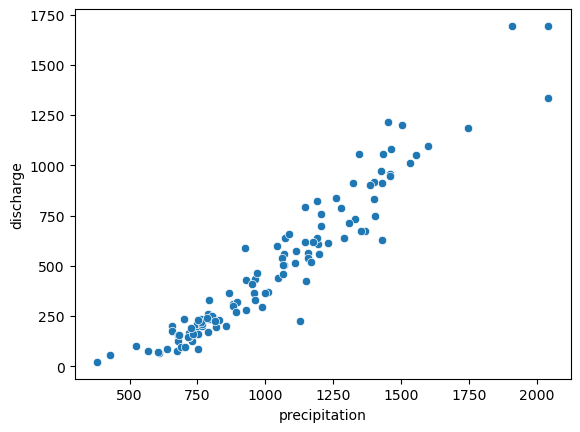

In [52]:
#scatter btw prec& discharge on year scale water year
precwy=precw.groupby('water year')['precipitation','discharge','pdsi'].sum()
precwy['discharge']=precwy['discharge']/12
precwy['pdsi']=precwy['pdsi']/12
precwy=precwy.reset_index().rename(columns={'mean':'precipitation'})
display(precwy)
sns.scatterplot(x=precwy["precipitation"], y=precwy["discharge"]);

In [53]:
#sns.histplot(data=precwy,x='Q/P',bins=15);

In [54]:
precwy['marked']=np.zeros(114).astype(int)
for row in precwy.itertuples():
    if precwy.at[row.Index, "water year"] in np.array([1924,1925,1952,1953,1973,1974,1976,1977,1996,1997,2014,2015,2021,2022]):
        precwy.at[row.Index, "marked"] = 1
precwy

,water year,precipitation,discharge,pdsi,marked
0,1908,654.83,198.211083,-0.078889,0
1,1909,1261.52,834.951667,-0.111667,0
2,1910,1073.88,638.822500,-0.875556,0
3,1911,1450.53,1213.716667,0.704167,0
4,1912,746.05,190.700000,-0.037222,0
...,...,...,...,...,...
109,2017,2041.52,1693.175000,1.203889,0
110,2018,950.13,409.325000,-1.511111,0
111,2019,1425.54,969.900000,0.892778,0
112,2020,753.15,231.991667,-1.845278,0


In [55]:
import plotly.express as px 
#import plotly.graph_objects as go
precwyy=precwy.copy()
precwyy['marked']=precwyy['marked'].astype(str)
px.scatter(precwyy, x="precipitation", y="discharge",color="marked",title='correlation between disccharge and precipitation by years')

###check where is outlier
color dots for yrs (9 largest shape areas could happen outside watershed

In [56]:
corr22=precwy['precipitation'].corr(precwy['discharge'])
corr22

0.9570098012691947

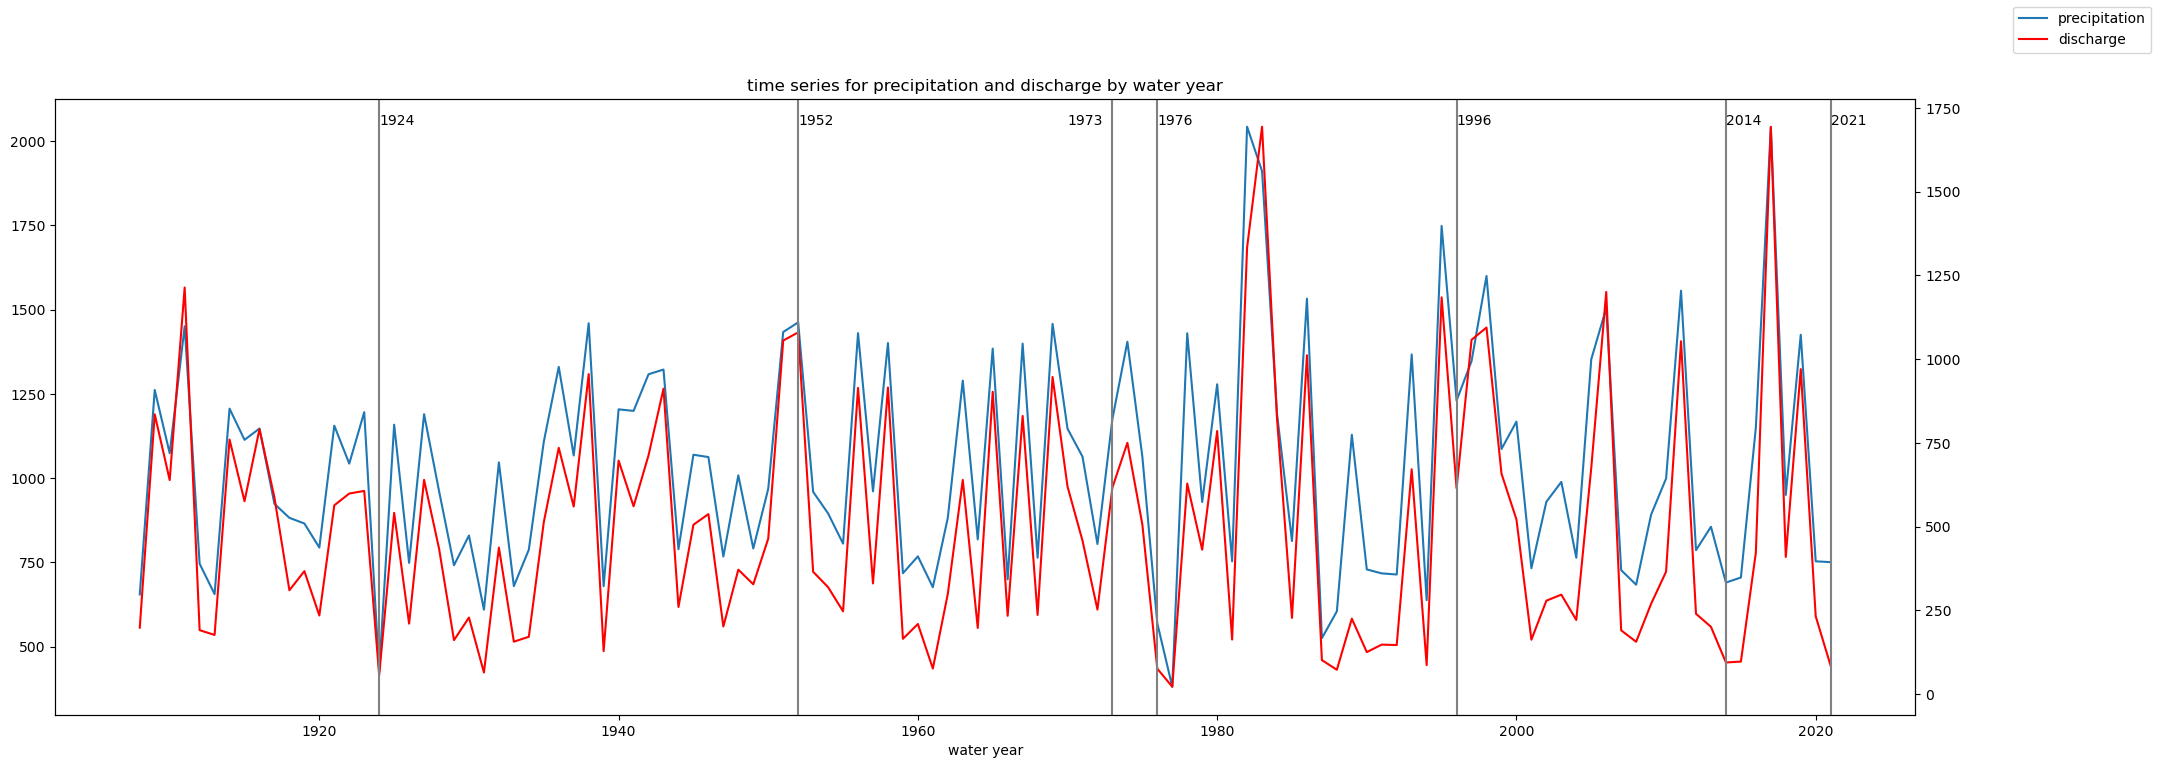

In [57]:
f,ax=plt.subplots(1,1,figsize=(24,8))
precwy.plot(x="water year", y="precipitation", ax=ax,legend=False)
ax2 = ax.twinx()
precwy.plot(x="water year", y="discharge", ax=ax2, legend=False, color="r")
ax.figure.legend()
plt.axvline(x=1924, color='grey')
plt.axvline(x=1952, color='grey')
plt.axvline(x=1973, color='grey')
plt.axvline(x=1976, color='grey')
plt.axvline(x=1996, color='grey')
plt.axvline(x=2014, color='grey')
plt.axvline(x=2021, color='grey')
plt.annotate('1924', xy=(1924, 160), xytext=(1924, 1700))
plt.annotate('1952', xy=(1952, 160), xytext=(1952,1700))
plt.annotate('1973', xy=(1973, 160), xytext=(1970, 1700))
plt.annotate('1976', xy=(1976, 160), xytext=(1976, 1700))
plt.annotate('1996', xy=(1996, 160), xytext=(1996, 1700))
plt.annotate('2014', xy=(2014, 160), xytext=(2014, 1700))
plt.annotate('2021', xy=(2021, 160), xytext=(2021, 1700))
plt.title('time series for precipitation and discharge by water year');

### add size and ratio for annual set

In [58]:
from math import e

precwy['log-size']=np.ones(114)
for row in precwy.itertuples():
    if (precwy.at[row.Index, "water year"] ==1924) or (precwy.at[row.Index, "water year"] ==1925):
        precwy.at[row.Index, "log-size"] = (4.440780e+07+3.621041e+07)/6.293836e+06  
    if (precwy.at[row.Index, "water year"] ==1952) or (precwy.at[row.Index, "water year"] ==1953):
        precwy.at[row.Index, "log-size"] = 6.293836e+06/6.293836e+06
    if ((precwy.at[row.Index, "water year"] ==1973) or (precwy.at[row.Index, "water year"] ==1974)):
        precwy.at[row.Index, "log-size"] = 4.174565e+07/6.293836e+06
    if ((precwy.at[row.Index, "water year"] ==1976) or (precwy.at[row.Index, "water year"] ==1977)):
        precwy.at[row.Index, "log-size"] = 8.445691e+07/6.293836e+06
    if ((precwy.at[row.Index, "water year"] ==1996) or (precwy.at[row.Index, "water year"] ==1997)):
        precwy.at[row.Index, "log-size"] = 3.572548e+07/6.293836e+06
    if ((precwy.at[row.Index, "water year"] ==2014) or (precwy.at[row.Index, "water year"] ==2015)):
        precwy.at[row.Index, "log-size"] = 1.715572e+07/6.293836e+06
    if ((precwy.at[row.Index, "water year"] ==2021) or (precwy.at[row.Index, "water year"] ==2021)):
        precwy.at[row.Index, "log-size"] = 8.975377e+08/6.293836e+06
#the relative sizes are still too large so we take the log transformation
precwy['log-size']=np.log(precwy['log-size'])

precwy['Q/P']=np.ones(114)
for row in precwy.itertuples():
    if (precwy.at[row.Index, "water year"] % 4==0) & (precwy.at[row.Index, "water year"] !=0):
        precwy.at[row.Index, "Q/P"] = precwy.at[row.Index, "discharge"]*1000*0.0283*366*24*60*60/(precwy.at[row.Index, "precipitation"]*1384527700)  
    else:
        precwy.at[row.Index, "Q/P"] = precwy.at[row.Index, "discharge"]*1000*0.0283*365*24*60*60/(precwy.at[row.Index, "precipitation"]*1384527700)
precwy

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P
0,1908,654.83,198.211083,-0.078889,0,0.000000,0.195650
1,1909,1261.52,834.951667,-0.111667,0,0.000000,0.426637
2,1910,1073.88,638.822500,-0.875556,0,0.000000,0.383456
3,1911,1450.53,1213.716667,0.704167,0,0.000000,0.539364
4,1912,746.05,190.700000,-0.037222,0,0.000000,0.165220
...,...,...,...,...,...,...,...
109,2017,2041.52,1693.175000,1.203889,0,0.000000,0.534613
110,2018,950.13,409.325000,-1.511111,0,0.000000,0.277700
111,2019,1425.54,969.900000,0.892778,0,0.000000,0.438570
112,2020,753.15,231.991667,-1.845278,0,0.000000,0.199100


### label years may get impacts on big fires

In [59]:
precwy['marked']=precwy['marked'].astype(str)
precwy["marked"] = 'no big fire'
for row in precwy.itertuples():
    if (precwy.at[row.Index, "water year"] ==1924) or (precwy.at[row.Index, "water year"] ==1925):
        precwy.at[row.Index, "marked"] = '1924/8'
    if (precwy.at[row.Index, "water year"] ==1952) or (precwy.at[row.Index, "water year"] ==1953):
        precwy.at[row.Index, "marked"] = '1952/8'
    if ((precwy.at[row.Index, "water year"] ==1973) or (precwy.at[row.Index, "water year"] ==1974)):
        precwy.at[row.Index, "marked"] = '1973/8'
    if ((precwy.at[row.Index, "water year"] ==1976) or (precwy.at[row.Index, "water year"] ==1977)):
        precwy.at[row.Index, "marked"] = '1976/6'
    if ((precwy.at[row.Index, "water year"] ==1996) or (precwy.at[row.Index, "water year"] ==1997)):
        precwy.at[row.Index, "marked"] = '1996/8'
    if ((precwy.at[row.Index, "water year"] ==2014) or (precwy.at[row.Index, "water year"] ==2015)):
        precwy.at[row.Index, "marked"] = '2014/8'
    if ((precwy.at[row.Index, "water year"] ==2021) or (precwy.at[row.Index, "water year"] ==2021)):
        precwy.at[row.Index, "marked"] = '2021/8'      

In [60]:
#distinguish fire year and the year after fire happened
ser=['fire year']
serobj=pd.Series(data=ser*114)
precwy['style']=serobj
for row in precwy.itertuples():
    if (precwy.at[row.Index, "water year"] ==1925) or (precwy.at[row.Index, "water year"] ==1953) or (precwy.at[row.Index, "water year"] ==1974) or (precwy.at[row.Index, "water year"] ==1977) or (precwy.at[row.Index, "water year"] ==1997) or (precwy.at[row.Index, "water year"] ==2015):
        precwy.at[row.Index, "style"] = 'year after fire year' 
display(precwy[precwy['style']=='year after fire year' ])

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style
17,1925,1158.51,540.921667,0.712222,1924/8,2.550154,0.300972,year after fire year
45,1953,959.30,365.033333,0.433056,1952/8,0.000000,0.245284,year after fire year
66,1974,1404.70,750.025000,0.444167,1973/8,1.892025,0.344178,year after fire year
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year
89,1997,1347.18,1057.508333,0.662222,1996/8,1.736293,0.505999,year after fire year
107,2015,705.18,96.951750,-3.962778,2014/8,1.002761,0.088623,year after fire year


### colored scatter plot differentiate by fire size, fire year

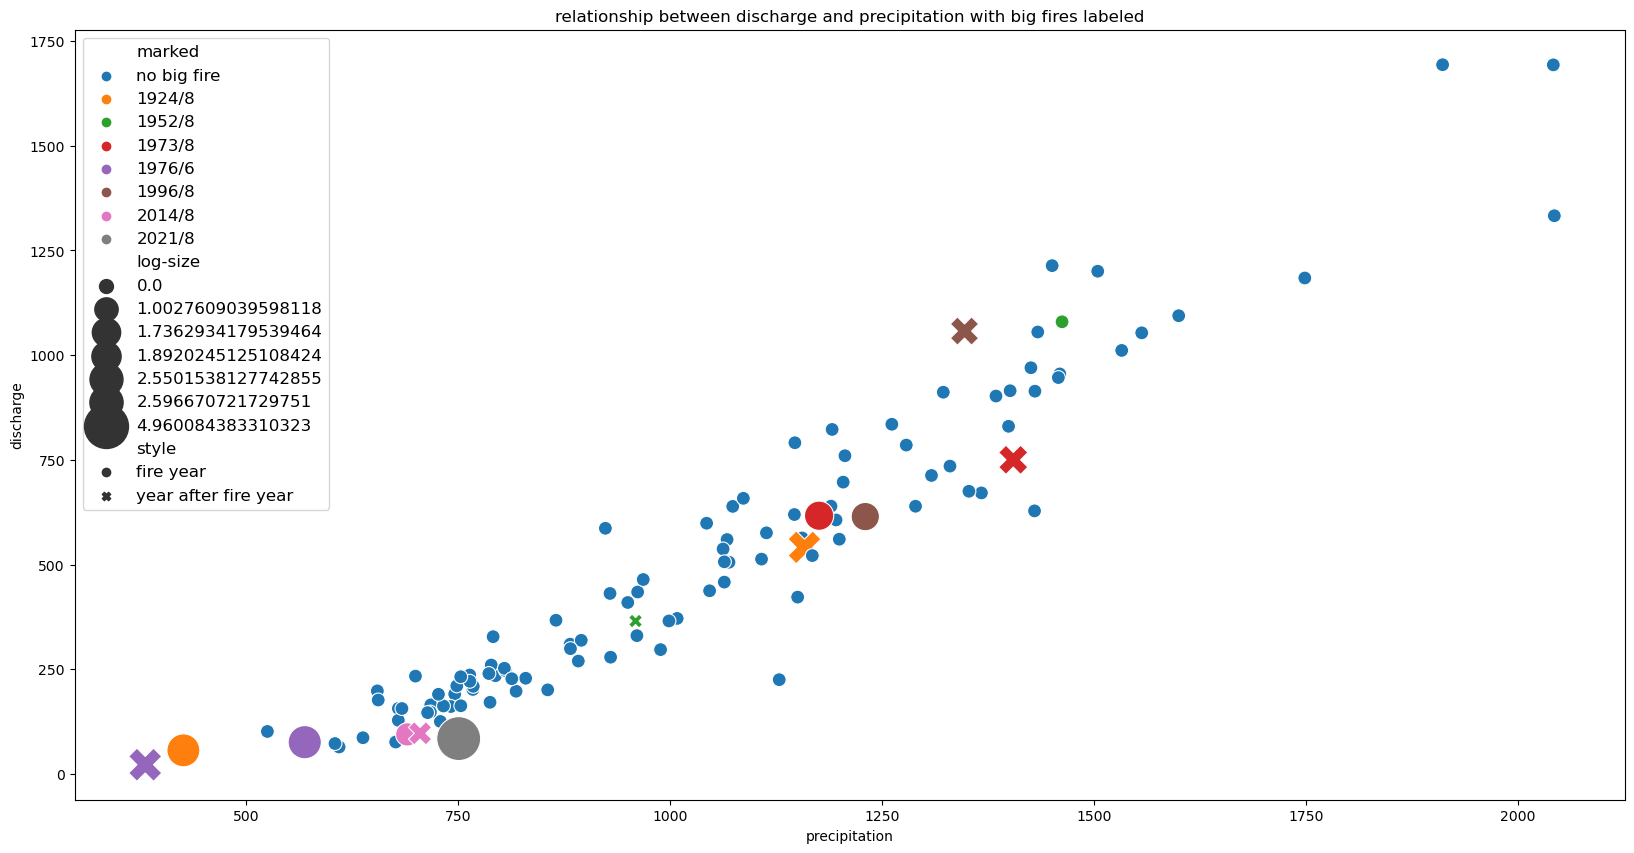

In [61]:
plt.figure(figsize=(20,10))
fig=sns.scatterplot(data=precwy, x="precipitation", y="discharge",size='log-size', sizes=(100, 1000), legend="full",hue='marked',style='style')
fig.legend(fontsize=12)
plt.title('relationship between discharge and precipitation with big fires labeled');

In [62]:
precwy.sort_values(by=['Q/P'])

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year
23,1931,609.72,64.195833,-2.227778,no big fire,0.000000,0.067868,fire year
113,2021,750.76,84.278333,-4.439444,2021/8,4.960084,0.072361,fire year
53,1961,676.41,76.072500,-2.358333,no big fire,0.000000,0.072495,fire year
80,1988,604.86,72.456000,-2.670556,no big fire,0.000000,0.077428,fire year
...,...,...,...,...,...,...,...,...
89,1997,1347.18,1057.508333,0.662222,1996/8,1.736293,0.505999,year after fire year
98,2006,1504.31,1200.425000,1.470556,no big fire,0.000000,0.514386,fire year
109,2017,2041.52,1693.175000,1.203889,no big fire,0.000000,0.534613,fire year
3,1911,1450.53,1213.716667,0.704167,no big fire,0.000000,0.539364,fire year


In [63]:
precwy['drought']=np.ones(114).astype(str)
precwy["drought"] = 'no'
for row in precwy.itertuples():
    if (precwy.at[row.Index, "pdsi"] <=-2) :
        precwy.at[row.Index, "drought"] = 'yes'
display(precwy)

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought
0,1908,654.83,198.211083,-0.078889,no big fire,0.000000,0.195650,fire year,no
1,1909,1261.52,834.951667,-0.111667,no big fire,0.000000,0.426637,fire year,no
2,1910,1073.88,638.822500,-0.875556,no big fire,0.000000,0.383456,fire year,no
3,1911,1450.53,1213.716667,0.704167,no big fire,0.000000,0.539364,fire year,no
4,1912,746.05,190.700000,-0.037222,no big fire,0.000000,0.165220,fire year,no
...,...,...,...,...,...,...,...,...,...
109,2017,2041.52,1693.175000,1.203889,no big fire,0.000000,0.534613,fire year,no
110,2018,950.13,409.325000,-1.511111,no big fire,0.000000,0.277700,fire year,no
111,2019,1425.54,969.900000,0.892778,no big fire,0.000000,0.438570,fire year,no
112,2020,753.15,231.991667,-1.845278,no big fire,0.000000,0.199100,fire year,no


In [64]:
train=precwy[precwy['marked']=='no big fire'] #nonfire years
display(train)
test=precwy[precwy['marked']!='no big fire'] #fire years
display(test)

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought
0,1908,654.83,198.211083,-0.078889,no big fire,0.0,0.195650,fire year,no
1,1909,1261.52,834.951667,-0.111667,no big fire,0.0,0.426637,fire year,no
2,1910,1073.88,638.822500,-0.875556,no big fire,0.0,0.383456,fire year,no
3,1911,1450.53,1213.716667,0.704167,no big fire,0.0,0.539364,fire year,no
4,1912,746.05,190.700000,-0.037222,no big fire,0.0,0.165220,fire year,no
...,...,...,...,...,...,...,...,...,...
108,2016,1150.43,422.154167,-1.226111,no big fire,0.0,0.237187,fire year,no
109,2017,2041.52,1693.175000,1.203889,no big fire,0.0,0.534613,fire year,no
110,2018,950.13,409.325000,-1.511111,no big fire,0.0,0.277700,fire year,no
111,2019,1425.54,969.900000,0.892778,no big fire,0.0,0.438570,fire year,no


,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought
16,1924,426.10,56.220250,-3.262222,1924/8,2.550154,0.085283,fire year,yes
17,1925,1158.51,540.921667,0.712222,1924/8,2.550154,0.300972,year after fire year,no
44,1952,1462.22,1079.566667,1.178056,1952/8,0.000000,0.477217,fire year,no
45,1953,959.30,365.033333,0.433056,1952/8,0.000000,0.245284,year after fire year,no
65,1973,1175.74,616.541667,0.097222,1973/8,1.892025,0.338020,fire year,no
66,1974,1404.70,750.025000,0.444167,1973/8,1.892025,0.344178,year after fire year,no
68,1976,569.20,75.699167,-2.302778,1976/6,2.596671,0.085962,fire year,yes
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year,yes
88,1996,1230.19,614.416667,3.265000,1996/8,1.736293,0.322827,fire year,no
89,1997,1347.18,1057.508333,0.662222,1996/8,1.736293,0.505999,year after fire year,no


In [65]:
dry=precwy[precwy['drought']=='yes']
drynf=dry[dry['marked']=='no big fire']
display(drynf)
dryf=dry[dry['marked']!='no big fire']
display(dryf)

,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought
10,1918,882.17,309.730000,-2.119444,no big fire,0.0,0.226320,fire year,yes
21,1929,741.52,160.895000,-2.102500,no big fire,0.0,0.139866,fire year,yes
23,1931,609.72,64.195833,-2.227778,no big fire,0.0,0.067868,fire year,yes
26,1934,787.68,170.970750,-2.040556,no big fire,0.0,0.139915,fire year,yes
51,1959,717.86,164.816667,-2.219722,no big fire,0.0,0.147997,fire year,yes
52,1960,767.89,209.085833,-2.870833,no big fire,0.0,0.175997,fire year,yes
53,1961,676.41,76.072500,-2.358333,no big fire,0.0,0.072495,fire year,yes
79,1987,525.16,101.323333,-2.376944,no big fire,0.0,0.124368,fire year,yes
80,1988,604.86,72.456000,-2.670556,no big fire,0.0,0.077428,fire year,yes
84,1992,714.07,146.267417,-2.321111,no big fire,0.0,0.132400,fire year,yes


,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought
16,1924,426.10,56.220250,-3.262222,1924/8,2.550154,0.085283,fire year,yes
68,1976,569.20,75.699167,-2.302778,1976/6,2.596671,0.085962,fire year,yes
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year,yes
106,2014,690.12,94.200833,-4.460000,2014/8,1.002761,0.087988,fire year,yes
107,2015,705.18,96.951750,-3.962778,2014/8,1.002761,0.088623,year after fire year,yes
113,2021,750.76,84.278333,-4.439444,2021/8,4.960084,0.072361,fire year,yes


In [66]:
sd2=np.std(drynf['Q/P'])
ave2=np.mean(drynf['Q/P'])
dryf['zscore']=(dryf['Q/P']-ave2)/sd2
dryf

/tmp/ipykernel_92/1439813050.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought,zscore
16,1924,426.10,56.220250,-3.262222,1924/8,2.550154,0.085283,fire year,yes,-1.368086
68,1976,569.20,75.699167,-2.302778,1976/6,2.596671,0.085962,fire year,yes,-1.352234
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year,yes,-2.495302
106,2014,690.12,94.200833,-4.460000,2014/8,1.002761,0.087988,fire year,yes,-1.304955
107,2015,705.18,96.951750,-3.962778,2014/8,1.002761,0.088623,year after fire year,yes,-1.290123
113,2021,750.76,84.278333,-4.439444,2021/8,4.960084,0.072361,fire year,yes,-1.669659


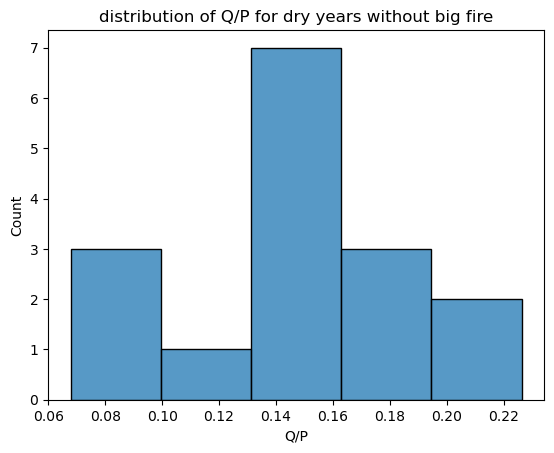

In [67]:
sns.histplot(data=drynf,x='Q/P')
plt.title('distribution of Q/P for dry years without big fire');

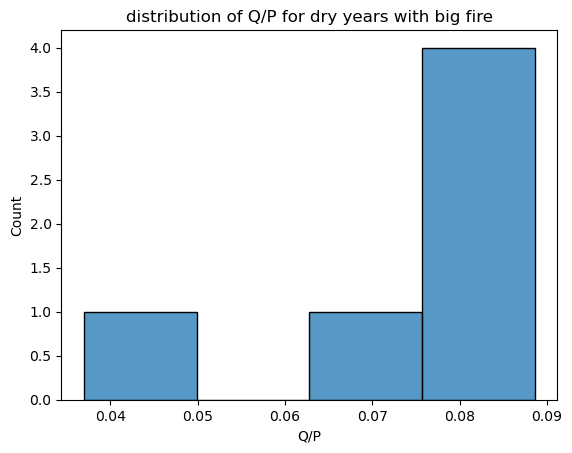

In [68]:
sns.histplot(data=dryf,x='Q/P')
plt.title('distribution of Q/P for dry years with big fire');

### classificatin of dry years

### stats test for ratio distribution

In [69]:
from scipy import stats
z=test[['Q/P']]
sd=np.std(train['Q/P'])
ave=np.mean(train['Q/P'])
test['zscore']=(test['Q/P']-ave)/sd
#test['zscore']=stats.zscore(test['Q/P'])
display(test)
sd,ave

/tmp/ipykernel_92/3980325061.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,water year,precipitation,discharge,pdsi,marked,log-size,Q/P,style,drought,zscore
16,1924,426.10,56.220250,-3.262222,1924/8,2.550154,0.085283,fire year,yes,-1.614400
17,1925,1158.51,540.921667,0.712222,1924/8,2.550154,0.300972,year after fire year,no,0.181814
44,1952,1462.22,1079.566667,1.178056,1952/8,0.000000,0.477217,fire year,no,1.649549
45,1953,959.30,365.033333,0.433056,1952/8,0.000000,0.245284,year after fire year,no,-0.281942
65,1973,1175.74,616.541667,0.097222,1973/8,1.892025,0.338020,fire year,no,0.490343
66,1974,1404.70,750.025000,0.444167,1973/8,1.892025,0.344178,year after fire year,no,0.541627
68,1976,569.20,75.699167,-2.302778,1976/6,2.596671,0.085962,fire year,yes,-1.608744
69,1977,381.10,21.866333,-3.493611,1976/6,2.596671,0.036985,year after fire year,yes,-2.016610
88,1996,1230.19,614.416667,3.265000,1996/8,1.736293,0.322827,fire year,no,0.363821
89,1997,1347.18,1057.508333,0.662222,1996/8,1.736293,0.505999,year after fire year,no,1.889234


(0.12007997310718796, 0.2791397503251603)

In [70]:
(0.037-0.28)/0.12

-2.0250000000000004

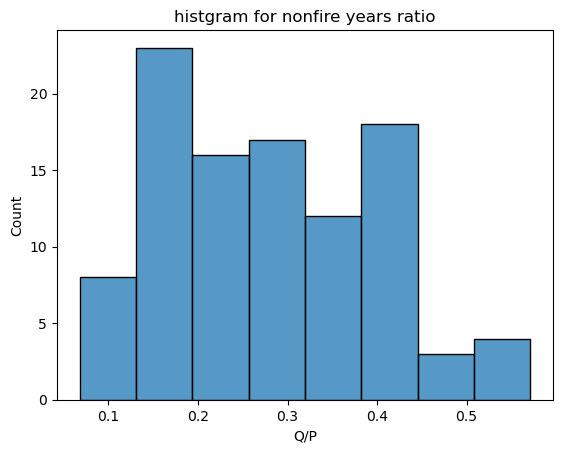

In [71]:
sns.histplot(data=train,x='Q/P')
plt.title('histgram for nonfire years ratio');

In [72]:
def rmse(predicted, actual):
    """
    Calculates RMSE from actual and predicted values
    Input:
      predicted (1D array): vector of predicted/fitted values
      actual (1D array): vector of actual values
    Output:
      a float, the root-mean square error
    """
    return np.sqrt(np.mean((actual - predicted)**2))

### lag and agg alogrithm

In [73]:
#attempt for lag method 
def df_shifted(df, target=None, lag=0):
    if not lag and not target:
        return df       
    new = {}
    for c in df.columns:
        if c == target:
            new[c] = df[target]
        else:
            new[c] = df[c].shift(periods=lag)
    return  pd.DataFrame(data=new)
#get highest val at lag=0
precwn=precw[['year','water year','month','water month','precipitation','discharge']]
precwn=precwn.rename(columns={'mean':'precipitation'})
precwn
df=precwn[['precipitation','discharge']]
display(df.corr())
display(df)

dflag0=df_shifted(df, target='discharge', lag=0)
display(dflag0)
display(dflag0.corr())


dflag1=df_shifted(df, target='discharge', lag=1)
display(dflag1)
display(dflag1.corr())

dflag2=df_shifted(df, target='discharge', lag=2)
display(dflag2)
display(dflag2.corr())

dflag3=df_shifted(df, target='discharge', lag=3)
display(dflag3)
display(dflag3.corr())

,precipitation,discharge
precipitation,1.000000,0.682106
discharge,0.682106,1.000000


,precipitation,discharge
0,25.53,67.00
1,6.39,76.70
2,206.19,195.30
3,132.90,448.70
4,84.52,291.80
...,...,...
1363,9.09,80.70
1364,0.28,18.00
1365,0.85,2.59
1366,98.11,0.00


,precipitation,discharge
0,25.53,67.00
1,6.39,76.70
2,206.19,195.30
3,132.90,448.70
4,84.52,291.80
...,...,...
1363,9.09,80.70
1364,0.28,18.00
1365,0.85,2.59
1366,98.11,0.00


,precipitation,discharge
precipitation,1.000000,0.682106
discharge,0.682106,1.000000


,precipitation,discharge
0,NaN,67.00
1,25.53,76.70
2,6.39,195.30
3,206.19,448.70
4,132.90,291.80
...,...,...
1363,9.17,80.70
1364,9.09,18.00
1365,0.28,2.59
1366,0.85,0.00


,precipitation,discharge
precipitation,1.000000,0.639476
discharge,0.639476,1.000000


,precipitation,discharge
0,NaN,67.00
1,NaN,76.70
2,25.53,195.30
3,6.39,448.70
4,206.19,291.80
...,...,...
1363,0.28,80.70
1364,9.17,18.00
1365,9.09,2.59
1366,0.28,0.00


,precipitation,discharge
precipitation,1.000000,0.512215
discharge,0.512215,1.000000


,precipitation,discharge
0,NaN,67.00
1,NaN,76.70
2,NaN,195.30
3,25.53,448.70
4,6.39,291.80
...,...,...
1363,281.22,80.70
1364,0.28,18.00
1365,9.17,2.59
1366,9.09,0.00


,precipitation,discharge
precipitation,1.000000,0.362931
discharge,0.362931,1.000000


In [74]:
precwn

,year,water year,month,water month,precipitation,discharge
0,1907,1908,10,1,25.53,67.00
1,1907,1908,11,2,6.39,76.70
2,1907,1908,12,3,206.19,195.30
3,1908,1908,1,4,132.90,448.70
4,1908,1908,2,5,84.52,291.80
...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70
1364,2021,2021,6,9,0.28,18.00
1365,2021,2021,7,10,0.85,2.59
1366,2021,2021,8,11,98.11,0.00


In [75]:
#plot stroggest scatter splot 2-3 strongest
#attempt for agg method try 2 months period
precwn
precwn['Rolling Average prec'] = precwn['precipitation'].rolling(2).mean()
precwn['Rolling Average disc'] = precwn['discharge'].rolling(2).mean()
display(precwn)
df2=precwn[['Rolling Average prec','Rolling Average disc']]
display(df2)
display(df2.corr())

#combine lag & agg
df2lag0=df_shifted(df2, target='Rolling Average disc', lag=0)
display(df2lag0)
display(df2lag0.corr())


df2lag1=df_shifted(df2, target='Rolling Average disc', lag=1)
display(df2lag1)
display(df2lag1.corr())

df2lag2=df_shifted(df2, target='Rolling Average disc', lag=2)
display(df2lag2)
display(df2lag2.corr())

df2lag3=df_shifted(df2, target='Rolling Average disc', lag=3)
display(df2lag3)
display(df2lag3.corr())
#highest val at lag1 0.8

,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,15.960,71.850
2,1907,1908,12,3,206.19,195.30,106.290,136.000
3,1908,1908,1,4,132.90,448.70,169.545,322.000
4,1908,1908,2,5,84.52,291.80,108.710,370.250
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,9.130,137.750
1364,2021,2021,6,9,0.28,18.00,4.685,49.350
1365,2021,2021,7,10,0.85,2.59,0.565,10.295
1366,2021,2021,8,11,98.11,0.00,49.480,1.295


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,15.960,71.850
2,106.290,136.000
3,169.545,322.000
4,108.710,370.250
...,...,...
1363,9.130,137.750
1364,4.685,49.350
1365,0.565,10.295
1366,49.480,1.295


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.699717
Rolling Average disc,0.699717,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,15.960,71.850
2,106.290,136.000
3,169.545,322.000
4,108.710,370.250
...,...,...
1363,9.130,137.750
1364,4.685,49.350
1365,0.565,10.295
1366,49.480,1.295


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.699717
Rolling Average disc,0.699717,1.000000


...

,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.808439
Rolling Average disc,0.808439,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,71.850
2,NaN,136.000
3,15.960,322.000
4,106.290,370.250
...,...,...
1363,140.750,137.750
1364,4.725,49.350
1365,9.130,10.295
1366,4.685,1.295


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.662459
Rolling Average disc,0.662459,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,71.850
2,NaN,136.000
3,NaN,322.000
4,15.960,370.250
...,...,...
1363,229.520,137.750
1364,140.750,49.350
1365,4.725,10.295
1366,9.130,1.295


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.467075
Rolling Average disc,0.467075,1.000000


In [76]:
#attempt for agg method try 3 months period
precwn
precwn['Rolling Average prec'] = precwn['precipitation'].rolling(3).mean()
precwn['Rolling Average disc'] = precwn['discharge'].rolling(3).mean()
display(precwn)
df3=precwn#[['Rolling Average prec','Rolling Average disc']]
display(df3)
display(df3[['Rolling Average prec','Rolling Average disc']].corr())

#combine lag & agg
df3lag0=df_shifted(df3, target='Rolling Average disc', lag=0)
display(df3lag0)
display(df3lag0.corr())


df3lag1=df_shifted(df3, target='Rolling Average disc', lag=1)
display(df3lag1)
display(df3lag1[['Rolling Average prec','Rolling Average disc']].corr())

df3lag2=df_shifted(df3, target='Rolling Average disc', lag=2)
display(df3lag2)
display(df3lag2[['Rolling Average prec','Rolling Average disc']].corr())

df3lag3=df_shifted(df3, target='Rolling Average disc', lag=3)
display(df3lag3)
display(df3lag3[['Rolling Average prec','Rolling Average disc']].corr())
#highest val at lag1 0.85


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,79.370000,113.000000
3,1908,1908,1,4,132.90,448.70,115.160000,240.233333
4,1908,1908,2,5,84.52,291.80,141.203333,311.933333
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,6.180000,173.733333
1364,2021,2021,6,9,0.28,18.00,6.180000,97.833333
1365,2021,2021,7,10,0.85,2.59,3.406667,33.763333
1366,2021,2021,8,11,98.11,0.00,33.080000,6.863333


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,79.370000,113.000000
3,1908,1908,1,4,132.90,448.70,115.160000,240.233333
4,1908,1908,2,5,84.52,291.80,141.203333,311.933333
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,6.180000,173.733333
1364,2021,2021,6,9,0.28,18.00,6.180000,97.833333
1365,2021,2021,7,10,0.85,2.59,3.406667,33.763333
1366,2021,2021,8,11,98.11,0.00,33.080000,6.863333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.713494
Rolling Average disc,0.713494,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,79.370000,113.000000
3,1908,1908,1,4,132.90,448.70,115.160000,240.233333
4,1908,1908,2,5,84.52,291.80,141.203333,311.933333
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,6.180000,173.733333
1364,2021,2021,6,9,0.28,18.00,6.180000,97.833333
1365,2021,2021,7,10,0.85,2.59,3.406667,33.763333
1366,2021,2021,8,11,98.11,0.00,33.080000,6.863333


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
year,1.000000,9.999134e-01,-9.902390e-03,9.902390e-03,0.020518,0.010456,0.028863,0.012160
water year,0.999913,1.000000e+00,-1.123857e-15,-5.157489e-17,0.022519,0.007655,0.027116,0.007634
month,-0.009902,-1.123857e-15,1.000000e+00,-1.328671e-01,-0.225795,-0.446243,-0.530916,-0.465849
water month,0.009902,-5.157489e-17,-1.328671e-01,1.000000e+00,-0.454510,-0.125648,-0.331396,0.051342
precipitation,0.020518,2.251905e-02,-2.257951e-01,-4.545103e-01,1.000000,0.682106,0.720551,0.294524
discharge,0.010456,7.654808e-03,-4.462434e-01,-1.256484e-01,0.682106,1.000000,0.806316,0.789010
Rolling Average prec,0.028863,2.711614e-02,-5.309164e-01,-3.313963e-01,0.720551,0.806316,1.000000,0.713494
Rolling Average disc,0.012160,7.633812e-03,-4.658492e-01,5.134216e-02,0.294524,0.789010,0.713494,1.000000


...

,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.852544
Rolling Average disc,0.852544,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1907.0,1908.0,10.0,1.0,25.53,67.00,NaN,113.000000
3,1907.0,1908.0,11.0,2.0,6.39,76.70,NaN,240.233333
4,1907.0,1908.0,12.0,3.0,206.19,195.30,79.370000,311.933333
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,3.0,6.0,0.28,245.70,153.106667,173.733333
1364,2021.0,2021.0,4.0,7.0,9.17,194.80,96.890000,97.833333
1365,2021.0,2021.0,5.0,8.0,9.09,80.70,6.180000,33.763333
1366,2021.0,2021.0,6.0,9.0,0.28,18.00,6.180000,6.863333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.782981
Rolling Average disc,0.782981,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,113.000000
3,1907.0,1908.0,10.0,1.0,25.53,67.0,NaN,240.233333
4,1907.0,1908.0,11.0,2.0,6.39,76.7,NaN,311.933333
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,2.0,5.0,281.22,216.2,182.286667,173.733333
1364,2021.0,2021.0,3.0,6.0,0.28,245.7,153.106667,97.833333
1365,2021.0,2021.0,4.0,7.0,9.17,194.8,96.890000,33.763333
1366,2021.0,2021.0,5.0,8.0,9.09,80.7,6.180000,6.863333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.546951
Rolling Average disc,0.546951,1.000000


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0,1907.10,25,67,0,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0,1907.11,6,76,0,113
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0,1907.12,206,195,79,240
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0,1908.01,132,448,115,311
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0,1908.02,84,291,141,417
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0,-4.393333,1.125484,897537700.0,2021.04,9,194,96,173
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0,2021.05,9,80,6,97
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0,2021.06,0,18,6,33
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0,2021.07,0,2,3,6


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
202,1924,1924,8,11,0.00,0.00,0.00,0.00,0.00,0.000,1,-5.350000,0.000000,80618210.0,1924.08,0,0,0,0
203,1924,1924,9,12,0.00,18.65,1.68,0.00,4.08,0.000,1,-5.156667,0.000000,80618210.0,1924.09,1,0,0,4
204,1924,1925,10,1,71.73,194.74,147.68,147.79,32.98,14.200,1,1.046667,0.005264,80618210.0,1924.10,147,14,49,34
205,1924,1925,11,2,48.00,105.51,75.75,74.25,15.46,88.900,1,0.043333,0.062178,80618210.0,1924.11,75,88,75,116
206,1924,1925,12,3,114.71,261.38,190.63,190.72,39.75,245.800,1,-0.003333,0.070591,80618210.0,1924.12,190,245,138,186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,2015,2015,6,9,0.00,39.97,13.53,5.54,13.33,16.800,1,-3.456667,0.065786,17155720.0,2015.06,13,16,44,23
1293,2015,2015,7,10,0.00,22.86,3.32,2.11,3.94,2.670,1,-3.230000,0.044028,17155720.0,2015.07,3,2,17,6
1294,2015,2015,8,11,0.00,5.34,0.50,0.00,0.98,0.021,1,-3.166667,0.002299,17155720.0,2015.08,0,0,5,0
1295,2015,2015,9,12,0.00,6.27,0.72,0.00,1.30,0.000,1,-3.143333,0.000000,17155720.0,2015.09,0,0,1,0


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1361,2021,2021,3,6,0.00,3.21,0.28,0.00,0.73,245.70,0
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0


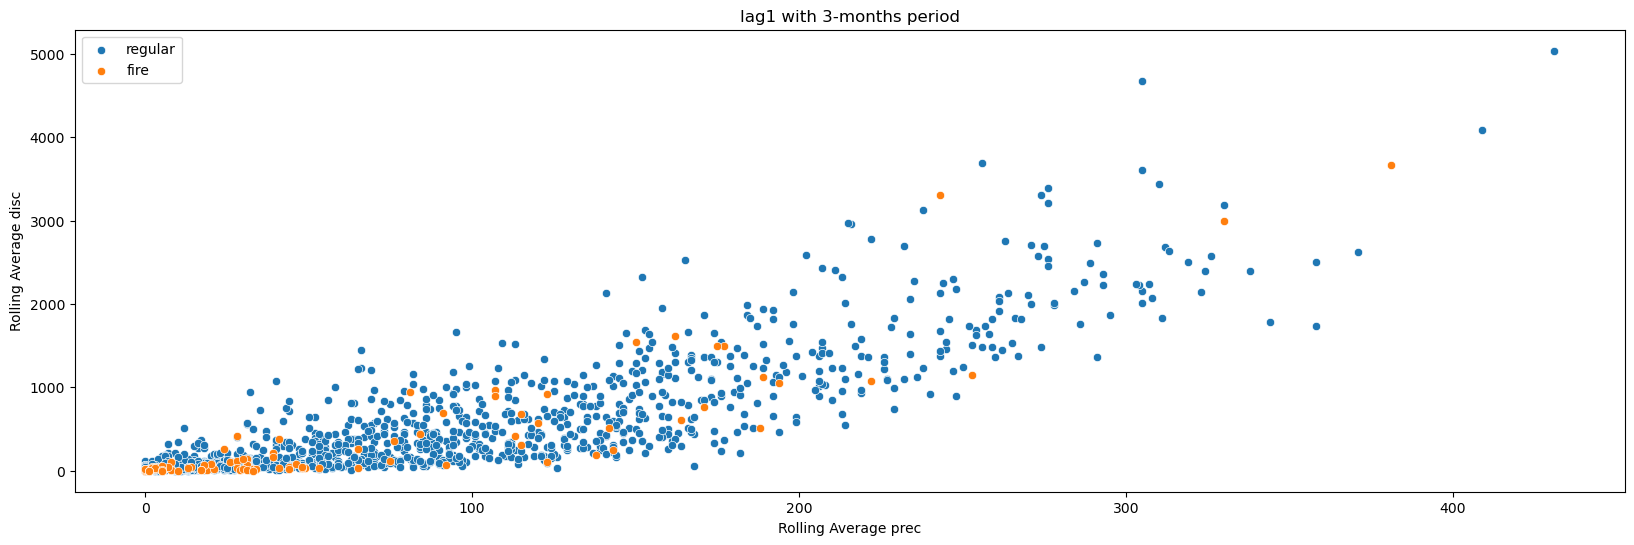

In [102]:
#lag1 period3 corr
df3lag1=df3lag1.fillna(0).astype(int)
df3lag11=precw.merge(df3lag1, how='inner', on=['year','water year','month','water month'])
display(df3lag11)
df3lag11f=df3lag11[df3lag11['marked']==1]
display(df3lag11f)
df3lag11nf=df3lag11[df3lag11['marked']==0]
display(precwnf)
#sns.scatterplot(data=precw,x="precipition", y="discharge",hue='marked');graph wlo overlay
plt.figure(figsize=(20,6))
sns.scatterplot(data=df3lag11nf,x="Rolling Average prec", y="Rolling Average disc",label='regular')
sns.scatterplot(data=df3lag11f,x="Rolling Average prec", y="Rolling Average disc",label='fire')
plt.title("lag1 with 3-months period");
#sns.scatterplot(data=df5lag11,x="Rolling Average prec", y="Rolling Average disc",hue='marked');

In [78]:
#attempt for agg method try 4 months period
precwn
precwn['Rolling Average prec'] = precwn['precipitation'].rolling(4).mean()
precwn['Rolling Average disc'] = precwn['discharge'].rolling(4).mean()
display(precwn)
df4=precwn[['Rolling Average prec','Rolling Average disc']]
display(df4)
display(df4.corr())

#combine lag & agg
df4lag0=df_shifted(df4, target='Rolling Average disc', lag=0)
display(df4lag0)
display(df4lag0.corr())


df4lag1=df_shifted(df4, target='Rolling Average disc', lag=1)
display(df4lag1)
display(df4lag1.corr())

df4lag2=df_shifted(df4, target='Rolling Average disc', lag=2)
display(df4lag2)
display(df4lag2.corr())

df4lag3=df_shifted(df4, target='Rolling Average disc', lag=3)
display(df4lag3)
display(df4lag3.corr())
#highest val at lag1 0.87

,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,92.7525,196.9250
4,1908,1908,2,5,84.52,291.80,107.5000,253.1250
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,74.9400,184.3500
1364,2021,2021,6,9,0.28,18.00,4.7050,134.8000
1365,2021,2021,7,10,0.85,2.59,4.8475,74.0225
1366,2021,2021,8,11,98.11,0.00,27.0825,25.3225


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,92.7525,196.9250
4,107.5000,253.1250
...,...,...
1363,74.9400,184.3500
1364,4.7050,134.8000
1365,4.8475,74.0225
1366,27.0825,25.3225


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.727673
Rolling Average disc,0.727673,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,92.7525,196.9250
4,107.5000,253.1250
...,...,...
1363,74.9400,184.3500
1364,4.7050,134.8000
1365,4.8475,74.0225
1366,27.0825,25.3225


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.727673
Rolling Average disc,0.727673,1.000000


...

,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.872811
Rolling Average disc,0.872811,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,196.9250
4,NaN,253.1250
...,...,...
1363,136.7850,184.3500
1364,117.1225,134.8000
1365,74.9400,74.0225
1366,4.7050,25.3225


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.830129
Rolling Average disc,0.830129,1.000000


,Rolling Average prec,Rolling Average disc
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,196.9250
4,NaN,253.1250
...,...,...
1363,155.9725,184.3500
1364,136.7850,134.8000
1365,117.1225,74.0225
1366,74.9400,25.3225


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.625401
Rolling Average disc,0.625401,1.000000


In [79]:
#attempt for agg method try 5 months period
precwn
precwn['Rolling Average prec'] = precwn['precipitation'].rolling(5).mean()
precwn['Rolling Average disc'] = precwn['discharge'].rolling(5).mean()
display(precwn)
df5=precwn#[['Rolling Average prec','Rolling Average disc']]
display(df5)
display(df5[['Rolling Average prec','Rolling Average disc']].corr())

#combine lag & agg
df5lag0=df_shifted(df5, target='Rolling Average disc', lag=0)
display(df5lag0)
display(df5lag0.corr())

###
df5lag1=df_shifted(df5, target='Rolling Average disc', lag=1)
display(df5lag1)
display(df5lag1[['Rolling Average prec','Rolling Average disc']].corr())

df5lag2=df_shifted(df5, target='Rolling Average disc', lag=2)
display(df5lag2)
display(df5lag2[['Rolling Average prec','Rolling Average disc']].corr())

df5lag3=df_shifted(df5, target='Rolling Average disc', lag=3)
display(df5lag3)
display(df5lag3[['Rolling Average prec','Rolling Average disc']].corr())
#highest val at lag1 0.88

#df5lag1f=df5lag1.merge(right=fireb,how='left',on=['year','month']).fillna(0)
#df5lag1f
#display(df5lag1f[df5lag1f['big fire']==1])

#plt.figure(figsize=(18,4))
#sns.scatterplot(data=df5lag1f, x="Rolling Average prec", y="Rolling Average disc", hue="big fire");


#sns.scatterplot(x=df5lag1["Rolling Average prec"], y=df5lag1["Rolling Average disc"]);

,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,91.106,215.900
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,95.516,180.720
1364,2021,2021,6,9,0.28,18.00,60.008,151.080
1365,2021,2021,7,10,0.85,2.59,3.934,108.358
1366,2021,2021,8,11,98.11,0.00,23.500,59.218


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,91.106,215.900
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,95.516,180.720
1364,2021,2021,6,9,0.28,18.00,60.008,151.080
1365,2021,2021,7,10,0.85,2.59,3.934,108.358
1366,2021,2021,8,11,98.11,0.00,23.500,59.218


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.741897
Rolling Average disc,0.741897,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,91.106,215.900
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,95.516,180.720
1364,2021,2021,6,9,0.28,18.00,60.008,151.080
1365,2021,2021,7,10,0.85,2.59,3.934,108.358
1366,2021,2021,8,11,98.11,0.00,23.500,59.218


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
year,1.000000,9.999134e-01,-9.902390e-03,9.902390e-03,0.020518,0.010456,0.037367,0.013087
water year,0.999913,1.000000e+00,-1.123857e-15,-5.157489e-17,0.022519,0.007655,0.032346,0.007633
month,-0.009902,-1.123857e-15,1.000000e+00,-1.328671e-01,-0.225795,-0.446243,-0.630227,-0.353359
water month,0.009902,-5.157489e-17,-1.328671e-01,1.000000e+00,-0.454510,-0.125648,-0.056624,0.269455
precipitation,0.020518,2.251905e-02,-2.257951e-01,-4.545103e-01,1.000000,0.682106,0.473525,0.050926
discharge,0.010456,7.654808e-03,-4.462434e-01,-1.256484e-01,0.682106,1.000000,0.782710,0.566729
Rolling Average prec,0.037367,3.234569e-02,-6.302268e-01,-5.662416e-02,0.473525,0.782710,1.000000,0.741897
Rolling Average disc,0.013087,7.633220e-03,-3.533587e-01,2.694546e-01,0.050926,0.566729,0.741897,1.000000


...

,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.880474
Rolling Average disc,0.880474,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1907.0,1908.0,10.0,1.0,25.53,67.00,NaN,NaN
3,1907.0,1908.0,11.0,2.0,6.39,76.70,NaN,NaN
4,1907.0,1908.0,12.0,3.0,206.19,195.30,NaN,215.900
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,3.0,6.0,0.28,245.70,124.834,180.720
1364,2021.0,2021.0,4.0,7.0,9.17,194.80,111.262,151.080
1365,2021.0,2021.0,5.0,8.0,9.09,80.70,95.516,108.358
1366,2021.0,2021.0,6.0,9.0,0.28,18.00,60.008,59.218


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.00000,0.84715
Rolling Average disc,0.84715,1.00000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1907.0,1908.0,10.0,1.0,25.53,67.0,NaN,NaN
4,1907.0,1908.0,11.0,2.0,6.39,76.7,NaN,215.900
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,2.0,5.0,281.22,216.2,124.778,180.720
1364,2021.0,2021.0,3.0,6.0,0.28,245.7,124.834,151.080
1365,2021.0,2021.0,4.0,7.0,9.17,194.8,111.262,108.358
1366,2021.0,2021.0,5.0,8.0,9.09,80.7,95.516,59.218


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.666014
Rolling Average disc,0.666014,1.000000


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0,1907.10,25,67,0,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0,1907.11,6,76,0,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0,1907.12,206,195,0,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0,1908.01,132,448,0,215
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0,1908.02,84,291,91,304
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0,-4.393333,1.125484,897537700.0,2021.04,9,194,111,180
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0,2021.05,9,80,95,151
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0,2021.06,0,18,60,108
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0,2021.07,0,2,3,59


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
202,1924,1924,8,11,0.00,0.00,0.00,0.00,0.00,0.000,1,-5.350000,0.000000,80618210.0,1924.08,0,0,6,10
203,1924,1924,9,12,0.00,18.65,1.68,0.00,4.08,0.000,1,-5.156667,0.000000,80618210.0,1924.09,1,0,0,3
204,1924,1925,10,1,71.73,194.74,147.68,147.79,32.98,14.200,1,1.046667,0.005264,80618210.0,1924.10,147,14,29,20
205,1924,1925,11,2,48.00,105.51,75.75,74.25,15.46,88.900,1,0.043333,0.062178,80618210.0,1924.11,75,88,45,69
206,1924,1925,12,3,114.71,261.38,190.63,190.72,39.75,245.800,1,-0.003333,0.070591,80618210.0,1924.12,190,245,83,114
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,2015,2015,6,9,0.00,39.97,13.53,5.54,13.33,16.800,1,-3.456667,0.065786,17155720.0,2015.06,13,16,65,45
1293,2015,2015,7,10,0.00,22.86,3.32,2.11,3.94,2.670,1,-3.230000,0.044028,17155720.0,2015.07,3,2,32,28
1294,2015,2015,8,11,0.00,5.34,0.50,0.00,0.98,0.021,1,-3.166667,0.002299,17155720.0,2015.08,0,0,27,14
1295,2015,2015,9,12,0.00,6.27,0.72,0.00,1.30,0.000,1,-3.143333,0.000000,17155720.0,2015.09,0,0,10,4


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1361,2021,2021,3,6,0.00,3.21,0.28,0.00,0.73,245.70,0
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0


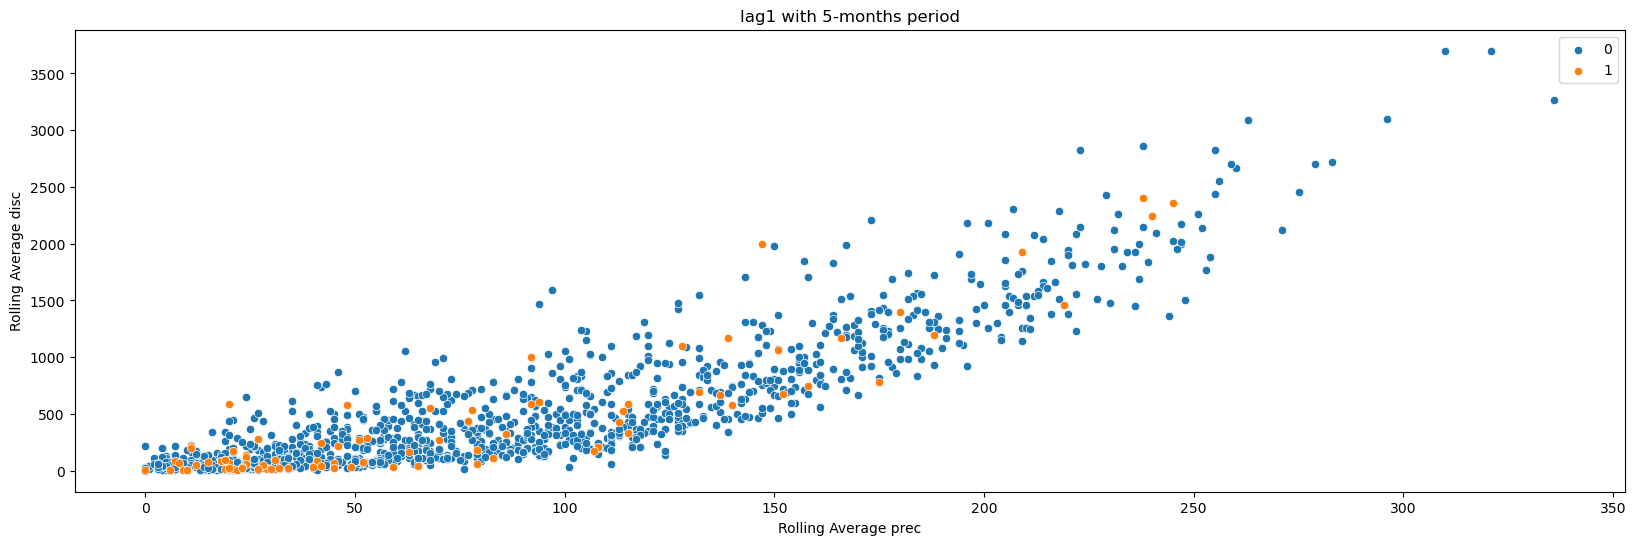

In [80]:
#lag1 period5 corr
df5lag1=df5lag1.fillna(0).astype(int)
df5lag11=precw.merge(df5lag1, how='inner', on=['year','water year','month','water month'])
display(df5lag11)
df5lag11f=df5lag11[df5lag11['marked']==1]
display(df5lag11f)
df5lag11nf=df5lag11[df5lag11['marked']==0]
display(precwnf)
#sns.scatterplot(data=precw,x="precipition", y="discharge",hue='marked');graph wlo overlay
plt.figure(figsize=(20,6))
sns.scatterplot(data=df5lag11nf,x="Rolling Average prec", y="Rolling Average disc",label='0')
sns.scatterplot(data=df5lag11f,x="Rolling Average prec", y="Rolling Average disc",label='1')
plt.title("lag1 with 5-months period");
#sns.scatterplot(data=df5lag11,x="Rolling Average prec", y="Rolling Average disc",hue='marked');

precwf=precw[precw['marked']==1]
display(precwf)
precwnf=precw[precw['marked']==0]
display(precwnf)

In [81]:
#attempt for agg method try 6 months period
precwn
precwn['Rolling Average prec'] = precwn['precipitation'].rolling(6).mean()
precwn['Rolling Average disc'] = precwn['discharge'].rolling(6).mean()
display(precwn)
df6=precwn#[['Rolling Average prec','Rolling Average disc']]
display(df6)
display(df6[['Rolling Average prec','Rolling Average disc']].corr())

#combine lag & agg
df6lag0=df_shifted(df6, target='Rolling Average disc', lag=0)
display(df6lag0)
display(df6lag0[['Rolling Average prec','Rolling Average disc']].corr())

###
df6lag1=df_shifted(df6, target='Rolling Average disc', lag=1)
display(df6lag1)
display(df6lag1[['Rolling Average prec','Rolling Average disc']].corr())

df6lag2=df_shifted(df6, target='Rolling Average disc', lag=2)
display(df6lag2)
display(df6lag2[['Rolling Average prec','Rolling Average disc']].corr())

df6lag3=df_shifted(df6, target='Rolling Average disc', lag=3)
display(df6lag3)
display(df6lag3[['Rolling Average prec','Rolling Average disc']].corr())
#highest val at lag1 0.88
#df6lag1f=df6lag1.merge(right=fireb,how='left',on=['year','month']).fillna(0)
#df6lag1f
#display(df6lag1f[df6lag1f['big fire']==1])

#plt.figure(figsize=(18,4))
#sns.scatterplot(data=df6lag1f, x="Rolling Average prec", y="Rolling Average disc", hue="big fire");

,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,NaN,NaN
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,94.233333,157.616667
1364,2021,2021,6,9,0.28,18.00,79.643333,153.600000
1365,2021,2021,7,10,0.85,2.59,50.148333,126.331667
1366,2021,2021,8,11,98.11,0.00,19.630000,90.298333


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,NaN,NaN
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,94.233333,157.616667
1364,2021,2021,6,9,0.28,18.00,79.643333,153.600000
1365,2021,2021,7,10,0.85,2.59,50.148333,126.331667
1366,2021,2021,8,11,98.11,0.00,19.630000,90.298333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.756053
Rolling Average disc,0.756053,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,25.53,67.00,NaN,NaN
1,1907,1908,11,2,6.39,76.70,NaN,NaN
2,1907,1908,12,3,206.19,195.30,NaN,NaN
3,1908,1908,1,4,132.90,448.70,NaN,NaN
4,1908,1908,2,5,84.52,291.80,NaN,NaN
...,...,...,...,...,...,...,...,...
1363,2021,2021,5,8,9.09,80.70,94.233333,157.616667
1364,2021,2021,6,9,0.28,18.00,79.643333,153.600000
1365,2021,2021,7,10,0.85,2.59,50.148333,126.331667
1366,2021,2021,8,11,98.11,0.00,19.630000,90.298333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.756053
Rolling Average disc,0.756053,1.000000


...

,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.883755
Rolling Average disc,0.883755,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1907.0,1908.0,10.0,1.0,25.53,67.00,NaN,NaN
3,1907.0,1908.0,11.0,2.0,6.39,76.70,NaN,NaN
4,1907.0,1908.0,12.0,3.0,206.19,195.30,NaN,NaN
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,3.0,6.0,0.28,245.70,104.028333,157.616667
1364,2021.0,2021.0,4.0,7.0,9.17,194.80,105.556667,153.600000
1365,2021.0,2021.0,5.0,8.0,9.09,80.70,94.233333,126.331667
1366,2021.0,2021.0,6.0,9.0,0.28,18.00,79.643333,90.298333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.855401
Rolling Average disc,0.855401,1.000000


,year,water year,month,water month,precipitation,discharge,Rolling Average prec,Rolling Average disc
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1907.0,1908.0,10.0,1.0,25.53,67.0,NaN,NaN
4,1907.0,1908.0,11.0,2.0,6.39,76.7,NaN,NaN
...,...,...,...,...,...,...,...,...
1363,2021.0,2021.0,2.0,5.0,281.22,216.2,104.003333,157.616667
1364,2021.0,2021.0,3.0,6.0,0.28,245.7,104.028333,153.600000
1365,2021.0,2021.0,4.0,7.0,9.17,194.8,105.556667,126.331667
1366,2021.0,2021.0,5.0,8.0,9.09,80.7,94.233333,90.298333


,Rolling Average prec,Rolling Average disc
Rolling Average prec,1.000000,0.693233
Rolling Average disc,0.693233,1.000000


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0,1.670000,0.143676,6293836.0,1907.10,25,67,0,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0,-0.933333,0.635937,6293836.0,1907.11,6,76,0,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0,-0.513333,0.051856,6293836.0,1907.12,206,195,0,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0,-0.780000,0.184838,6293836.0,1908.01,132,448,0,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0,-0.700000,0.170719,6293836.0,1908.02,84,291,0,265
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0,-4.393333,1.125484,897537700.0,2021.04,9,194,105,157
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0,-4.846667,0.486038,897537700.0,2021.05,9,80,94,153
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0,-5.496667,3.405919,897537700.0,2021.06,0,18,79,126
1365,2021,2021,7,10,0.00,5.79,0.85,0.00,1.71,2.59,0,-5.906667,0.166817,897537700.0,2021.07,0,2,50,90


,year,water year,month,water month,min,max,precipitation_x,median,std,discharge_x,marked,pdsi,Q/P,size,time,precipitation_y,discharge_y,Rolling Average prec,Rolling Average disc
202,1924,1924,8,11,0.00,0.00,0.00,0.00,0.00,0.000,1,-5.350000,0.000000,80618210.0,1924.08,0,0,20,32
203,1924,1924,9,12,0.00,18.65,1.68,0.00,4.08,0.000,1,-5.156667,0.000000,80618210.0,1924.09,1,0,5,11
204,1924,1925,10,1,71.73,194.74,147.68,147.79,32.98,14.200,1,1.046667,0.005264,80618210.0,1924.10,147,14,25,17
205,1924,1925,11,2,48.00,105.51,75.75,74.25,15.46,88.900,1,0.043333,0.062178,80618210.0,1924.11,75,88,37,58
206,1924,1925,12,3,114.71,261.38,190.63,190.72,39.75,245.800,1,-0.003333,0.070591,80618210.0,1924.12,190,245,69,95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,2015,2015,6,9,0.00,39.97,13.53,5.54,13.33,16.800,1,-3.456667,0.065786,17155720.0,2015.06,13,16,55,141
1293,2015,2015,7,10,0.00,22.86,3.32,2.11,3.94,2.670,1,-3.230000,0.044028,17155720.0,2015.07,3,2,55,38
1294,2015,2015,8,11,0.00,5.34,0.50,0.00,0.98,0.021,1,-3.166667,0.002299,17155720.0,2015.08,0,0,26,23
1295,2015,2015,9,12,0.00,6.27,0.72,0.00,1.30,0.000,1,-3.143333,0.000000,17155720.0,2015.09,0,0,22,12


,year,water year,month,water month,min,max,precipitation,median,std,discharge,marked
0,1907,1908,10,1,14.22,37.86,25.53,25.86,6.95,67.00,0
1,1907,1908,11,2,2.39,11.27,6.39,6.56,1.74,76.70,0
2,1907,1908,12,3,109.85,312.20,206.19,202.43,53.86,195.30,0
3,1908,1908,1,4,106.32,173.70,132.90,130.96,16.83,448.70,0
4,1908,1908,2,5,62.35,108.53,84.52,83.22,12.14,291.80,0
...,...,...,...,...,...,...,...,...,...,...,...
1361,2021,2021,3,6,0.00,3.21,0.28,0.00,0.73,245.70,0
1362,2021,2021,4,7,0.35,25.98,9.17,7.25,7.29,194.80,0
1363,2021,2021,5,8,2.44,11.79,9.09,9.50,1.92,80.70,0
1364,2021,2021,6,9,0.00,3.21,0.28,0.00,0.73,18.00,0


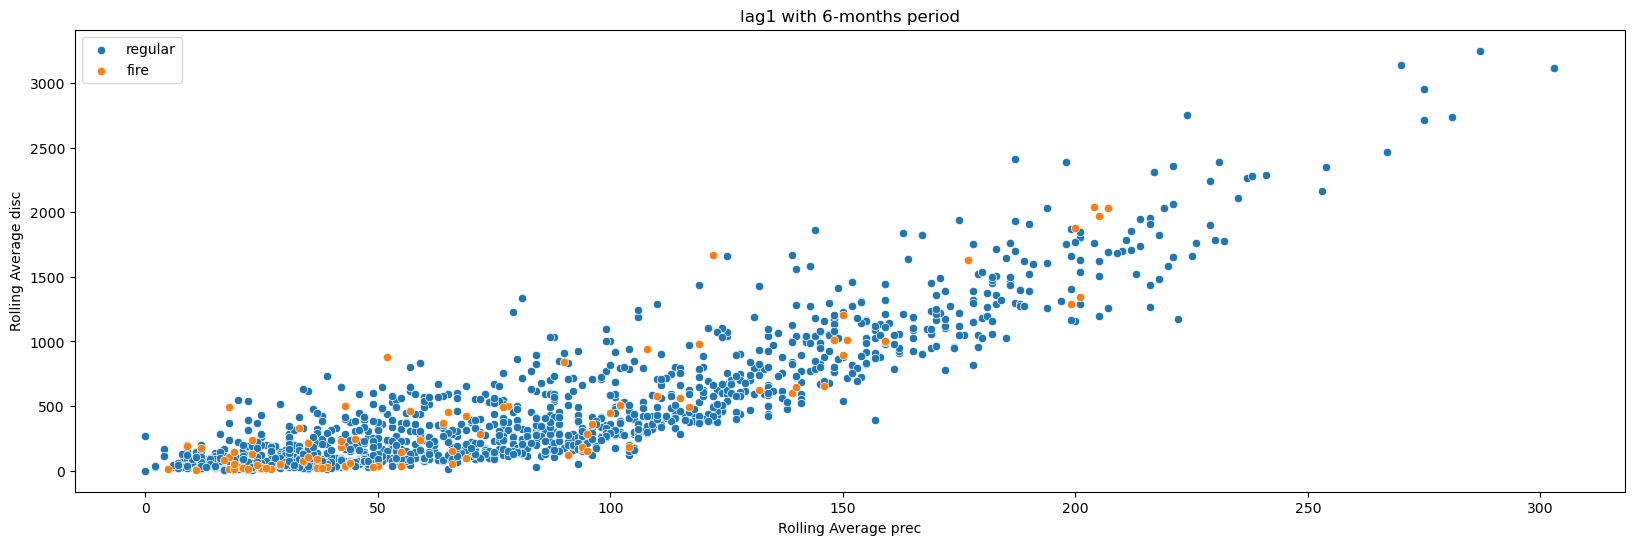

In [103]:
#lag1 period6 corr
df6lag1=df6lag1.fillna(0).astype(int)
df6lag11=precw.merge(df6lag1, how='inner', on=['year','water year','month','water month'])
display(df6lag11)
df6lag11f=df6lag11[df6lag11['marked']==1]
display(df6lag11f)
df6lag11nf=df6lag11[df6lag11['marked']==0]
display(precwnf)
#sns.scatterplot(data=precw,x="precipition", y="discharge",hue='marked');graph wlo overlay
plt.figure(figsize=(20,6))
sns.scatterplot(data=df6lag11nf,x="Rolling Average prec", y="Rolling Average disc",label='regular')
sns.scatterplot(data=df6lag11f,x="Rolling Average prec", y="Rolling Average disc",label='fire')
plt.title("lag1 with 6-months period");
#sns.scatterplot(data=df5lag11,x="Rolling Average prec", y="Rolling Average disc",hue='marked');

### discharge daily

In [83]:
daily=pd.read_csv('discharge daily.csv')#usgs daily discharge 1907-2022
daily

,date,discharge
0,10/1/1907,67
1,10/2/1907,67
2,10/3/1907,67
3,10/4/1907,67
4,10/5/1907,67
...,...,...
41924,7/13/2022,40
41925,7/14/2022,39
41926,7/15/2022,38
41927,7/16/2022,37


In [84]:
daily['date']= pd.to_datetime(daily['date'])
daily['year'] = daily['date'].dt.year
daily['month']= daily['date'].dt.month
daily['day']= daily['date'].dt.day
daily=daily[['year', 'month', 'day', 'discharge']]
daily

,year,month,day,discharge
0,1907,10,1,67
1,1907,10,2,67
2,1907,10,3,67
3,1907,10,4,67
4,1907,10,5,67
...,...,...,...,...
41924,2022,7,13,40
41925,2022,7,14,39
41926,2022,7,15,38
41927,2022,7,16,37


In [85]:
###get water month
daily['month']=daily['month'].astype(str)
dailyw=daily.copy()
orginm2=daily['month']
orginy2=daily['year']
factor_dict= {'month':{'10':1 ,'11':2,'12':3,'1': 4,'2':5,'3': 6,'4':7,'5':8,'6':9,'7':10,'8':11,'9':12}}
#precdfix=prec.copy()
dailyw.replace(factor_dict, inplace=True)
#precfix
dailyw=dailyw.rename(columns={'month':'water month'})
dailyw['month']=orginm2.astype(int)
dailyw

/tmp/ipykernel_92/1640033176.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,year,water month,day,discharge,month
0,1907,1,1,67,10
1,1907,1,2,67,10
2,1907,1,3,67,10
3,1907,1,4,67,10
4,1907,1,5,67,10
...,...,...,...,...,...
41924,2022,10,13,40,7
41925,2022,10,14,39,7
41926,2022,10,15,38,7
41927,2022,10,16,37,7


In [86]:
###get water year
for row in dailyw.itertuples():
    if dailyw.at[row.Index, "month"] >=10:
        dailyw.at[row.Index, "year"] = dailyw.at[row.Index, "year"]+1
dailyw=dailyw.rename(columns={'year':'water year'})
dailyw['year']=orginy2
dailyw 

,water year,water month,day,discharge,month,year
0,1908,1,1,67,10,1907
1,1908,1,2,67,10,1907
2,1908,1,3,67,10,1907
3,1908,1,4,67,10,1907
4,1908,1,5,67,10,1907
...,...,...,...,...,...,...
41924,2022,10,13,40,7,2022
41925,2022,10,14,39,7,2022
41926,2022,10,15,38,7,2022
41927,2022,10,16,37,7,2022


In [87]:
flow1997=dailyw [(dailyw['water year']==1997)&(dailyw['water month']==4)] #check water year 1997 water month 3,4,5
flow1997

,water year,water month,day,discharge,month,year
32600,1997,4,1,25300,1,1997
32601,1997,4,2,61600,1,1997
32602,1997,4,3,19100,1,1997
32603,1997,4,4,8520,1,1997
32604,1997,4,5,5580,1,1997
32605,1997,4,6,4090,1,1997
32606,1997,4,7,3220,1,1997
32607,1997,4,8,2680,1,1997
32608,1997,4,9,2280,1,1997
32609,1997,4,10,2020,1,1997


In [88]:
dailyw [dailyw['water year']==1909]['discharge'].max()

20800

### analysis for annual max discharge with gumbel distribution

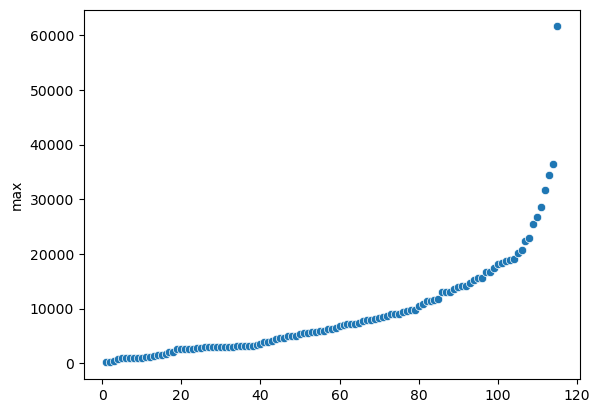

In [89]:
new=dailyw[['water year','discharge']]
m=new.groupby('water year').max()['discharge'].to_frame().reset_index().rename(columns={'discharge':'max'})
n=new.groupby('water year').min()['discharge'].to_frame().reset_index().rename(columns={'discharge':'min'})
extreme=m.merge(n,on='water year')
extreme
mm=extreme['max'].sort_values()
nn=extreme['min'].sort_values()
sns.scatterplot(x=np.arange(1,116), y=mm);
#extreme['min']=extreme.groupby('water year').min()['discharge']

In [90]:
extreme.to_csv("extreme.csv")

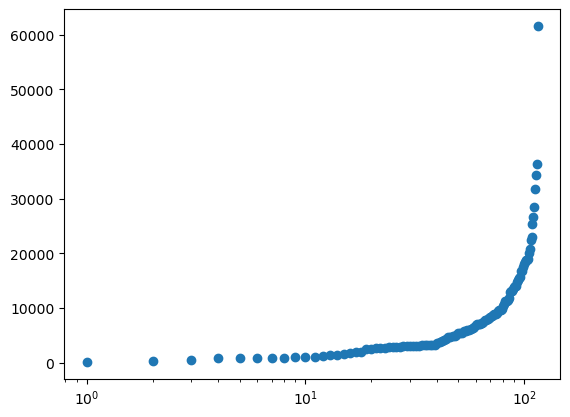

In [91]:
plt.semilogx(np.arange(1,116), mm,'o');

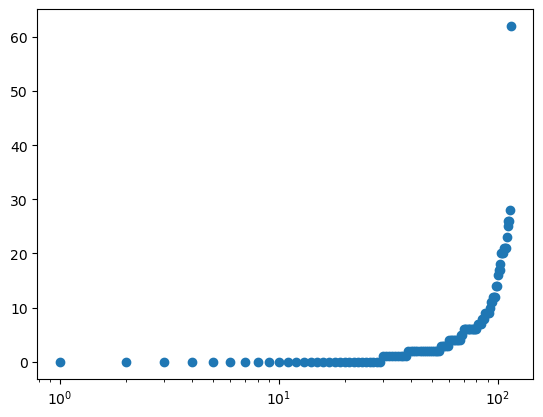

In [92]:
plt.semilogx(np.arange(1,116),nn,'o');

In [93]:
extreme[extreme['max']>60000]

,water year,max,min
89,1997,61600,20


In [94]:
extreme[extreme['min']>60]

,water year,max,min
75,1983,18400,62


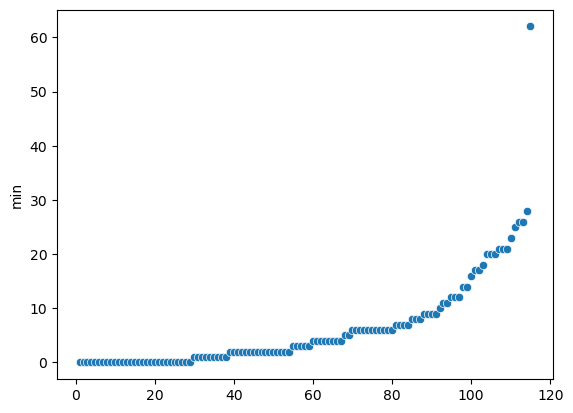

In [95]:
sns.scatterplot(x=np.arange(1,116), y=nn);

discharge prec scatter
year vs burn area

firep17_1: wildfire perimeters from contributing agencies current as 2017;\
rxburn17_1: prescribed fires supplied from contributing agencies current as 2017;\
Non_Fire: non-prescribed fire fuel reduction projects that were initially included in the database. Fuels reduction projects that are non prescribed fire are no longer included

In [96]:
doc=pd.read_csv('documentation.csv')
doc

,ITEM NAME,DATA TYPE,DESCRIPTION,Domain
0,YEAR_,Text,Fire Year,No
1,STATE,Text,State,Yes
2,AGENCY,Text,Direct protection agency responsible for fire,Yes
3,UNIT_ID,Text,ICS code for unit,Yes
4,FIRE_NAME,Text,Name of the fire,No
5,INC_NUM,Text,Number assigned by the Emergency Command Cente...,No
6,ALARM_DATE,Date,Alarm date for fire,No
7,CONT_DATE,Date,Containment date for fire,No
8,CAUSE,Integer,Reason fire ignited,Yes
9,COMMENTS,Text,Miscellaneous comments,No


Agency ID	Description

       CA	California
       NV	Nevada
       OR	Oregon
       AZ	Arizona
        
Agency        Description

    BIA	USDI Bureau of Indian Affairs
    BLM	Bureau of Land Management
    CDF	California Department of Forestry and Fire Protection
    CCO	Contract Counties
    DOD	Department of Defense
    FWS	USDI Fish and Wildlife Service
    LRA	Local Response Area
    NOP	No Protection
    NPS	National Park Service
    PVT	Private
    USF	United States Forest Service
    OTH	Other
   
    **Cause Code	Description**
        1	Lightning
        2	Equipment Use
        3	Smoking
        4	Campfire
        5	Debris
        6	Railroad
        7	Arson
        8	Playing with Fire
        9	Miscellaneous
        10	Vehicle
        11	Power Line
        12	Firefighter Training
        13	Non-Firefighter Training
        14	Unknown/Unidentified
        15	Structure
        16	Aircraft
        17	Volcanic
        18	Escaped Prescribed Burn
        19	Illegal Alien Campfire

    Collect Method Code	Description
                1	GPS Ground
                2	GPS Air
                3	Infrared
                4	Other Imagery
                5	Photo Interpretation
                6	Hand Drawn
                7	Mixed Collection Methods
                8	Unknown
                
    Objective Code	Description
            1	Suppression (Wildfire)
            2	Resource Benefit (WFU)

In [97]:
#unit:square metre

firep=pd.read_csv('firep21.csv').drop(columns=['STATE','COMMENTS','OBJECTIVE']).rename(columns={"YEAR_": "year",'ALARM_DATE':'month','area':'area(m^2)'}).drop(columns=['Shape_Leng','CONT_DATE'])
#firep=firep[firep['year']>=1991]
#firep=firep[firep['year']<2021]
firep['month']=firep['month'].str.extract('/(\d+)/').fillna(0).astype(int)#only offer date not exactly time on that day
firep=firep.sort_values(by=['year','month']).reset_index().drop(columns=['index'])

col = firep.pop('month')  
firep.insert(2, 'month', col)
#firep['GIS_ACRES']=
display(firep)
firep=firep.sort_values('Shape_Area',ascending=False)
display(firep.head(11))

#firep['big fire']=np.concatenate((np.ones(9), np.zeros(97)), axis=0).astype(int)
#firep=firep.sort_values(['year','month'])
#fireb=firep[['year','month','big fire']]
#fireb=fireb[fireb['month']!=0]
#fireb

,OBJECTID,year,month,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,CAUSE,REPORT_AC,GIS_ACRES,C_METHOD,FIRE_NUM,Shape_Area,area(m^2)
0,26736,1916,0,USF,ENF,NaN,00000000,9,NaN,32.251324,NaN,0000P275,1.305165e+05,1.305165e+05
1,26737,1916,0,USF,ENF,NaN,00000000,9,NaN,1397.120483,NaN,0000C261,5.653946e+06,5.653946e+06
2,29920,1917,0,USF,ENF,NaN,00000000,14,NaN,698.911865,NaN,00000000,2.828396e+06,2.828396e+06
3,29922,1917,0,USF,ENF,NaN,00000000,14,NaN,10058.083984,NaN,00000000,4.070362e+07,1.216478e+07
4,26886,1919,0,USF,ENF,NaN,00000000,9,NaN,603.147827,NaN,00000032,2.440853e+06,2.440853e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101,42853,2021,5,CDF,AEU,BELL,00013708,2,18.37,18.612055,1.0,NaN,7.532031e+04,7.532032e+04
102,42858,2021,5,CDF,AEU,SETTLERS,00013605,2,45.15,45.351231,1.0,NaN,1.835299e+05,1.835299e+05
103,42856,2021,6,CDF,AEU,STEINS,00018047,9,14.06,13.732354,1.0,NaN,5.557287e+04,5.557287e+04
104,43102,2021,8,USF,ENF,CALDOR,00024030,14,221835.00,221786.390625,7.0,NaN,8.975377e+08,4.043511e+08


,OBJECTID,year,month,AGENCY,UNIT_ID,FIRE_NAME,INC_NUM,CAUSE,REPORT_AC,GIS_ACRES,C_METHOD,FIRE_NUM,Shape_Area,area(m^2)
104,43102,2021,8,USF,ENF,CALDOR,00024030,14,221835.0,221786.390625,7.0,NaN,8.975377e+08,4.043511e+08
54,29371,1976,6,CDF,AEU,QUARRY,00000000,14,NaN,20869.755859,NaN,00000206,8.445691e+07,7.828336e+07
15,22616,1924,8,USF,ENF,UPPER DESOLATION VAL,00000000,14,NaN,10973.407227,NaN,000038C5,4.440780e+07,4.440780e+07
52,36882,1973,8,USF,ENF,PILLIKEN,00000000,7,9990.0,10315.574219,8.0,00000072,4.174565e+07,1.464357e+06
3,29922,1917,0,USF,ENF,NaN,00000000,14,NaN,10058.083984,NaN,00000000,4.070362e+07,1.216478e+07
14,22605,1924,8,USF,ENF,PI PI-INDIAN DIGGING,00000000,9,NaN,8947.786133,NaN,000013C2,3.621041e+07,7.981004e+06
61,27653,1996,8,CDF,AEU,SCOTT,00002866,7,NaN,8827.958008,NaN,00000345,3.572548e+07,9.267867e+06
88,39695,2014,7,CDF,AEU,SAND,018237,10,4240.0,4239.271973,1.0,NaN,1.715572e+07,1.715572e+07
36,23363,1952,8,CDF,AEU,DRESSLER,00000000,14,NaN,1555.240845,NaN,00000102,6.293836e+06,6.293836e+06
1,26737,1916,0,USF,ENF,NaN,00000000,9,NaN,1397.120483,NaN,0000C261,5.653946e+06,5.653946e+06


In [98]:
#precwf=precw.merge(right=fireb,how='left',on=['year','month']).fillna(0)
#precwf
#display(precwf[precwf['big fire']==1])
#sns.scatterplot(data=precwf, x="mean", y="discharge", hue="big fire")
#plt.xlabel("precipition");

In [99]:
firey=firep.iloc[:, [1,-1]]
firey
#firep['area']=firep.groupby('year')['area(m^2)'].mean()
#firep

,year,area(m^2)
104,2021,4.043511e+08
54,1976,7.828336e+07
15,1924,4.440780e+07
52,1973,1.464357e+06
3,1917,1.216478e+07
...,...,...
8,1920,3.397614e+04
76,2005,2.294869e+04
10,1921,1.487324e+04
96,2019,9.867753e+03


In [100]:
#non-prescribed fire
nonrxfire=pd.read_csv('nonrxfire.csv').rename(columns={"YEAR_": "year",'END_DATE':'month','area':'area(m^2)'}).drop(columns=['Shape_Leng','START_DATE'])
nonrxfire['month']=nonrxfire['month'].str.extract('/(\d+)/').fillna(0).astype(int)
nonrxfire=nonrxfire.sort_values(by=['year','month']).reset_index().drop(columns=['index'])

col1 = nonrxfire.pop('year')  
nonrxfire.insert(1, 'year', col1)
col1 = nonrxfire.pop('month')  
nonrxfire.insert(2, 'month', col1)
nonrxfire

,OBJECTID,year,month,TREATMENT_,TREATMEN_1,TREATMEN_2,UNIT_ID,AGENCY,TREATED_AC,GIS_ACRES,STATE,RX_CONSUM,PRE_CON_CL,POST_CON_C,Shape_Area,area(m^2)
0,826,2006,2,3271145.0,06 PLV,10,ENF,USF,885.089345,885.089966,CA,NaN,NaN,NaN,3.581832e+06,3581832.094
1,110,2006,9,3279745.0,06 OWL II STUDY SM TREE THIN,2,ENF,USF,130.958728,130.958984,CA,NaN,NaN,NaN,5.299722e+05,529972.198
2,111,2006,9,3279746.0,06 OWL II STUDY MAC PILE,13,ENF,USF,201.235305,201.234833,CA,NaN,NaN,NaN,8.143685e+05,357036.949
3,873,2010,0,NaN,SLY PARK,10,AEU,CDF,NaN,31.696766,CA,3.0,2.0,1.0,1.282723e+05,128272.262
4,874,2010,0,NaN,SLY PARK,10,AEU,CDF,NaN,4.688349,CA,3.0,2.0,2.0,1.897307e+04,18973.074
5,875,2010,0,NaN,SHAKE/ FIDDLE,10,AEU,CDF,NaN,0.154115,CA,3.0,2.0,2.0,6.236793e+02,623.679
6,876,2010,0,NaN,SHAKE/ FIDDLE,10,AEU,CDF,NaN,15.072478,CA,3.0,2.0,2.0,6.099616e+04,60996.155
7,877,2010,0,NaN,SHAKE/ FIDDLE,10,AEU,CDF,NaN,10.265574,CA,3.0,2.0,2.0,4.154331e+04,40423.811
8,928,2015,6,3105.0,2015 Spring Piles,10,AEU,CDF,7.300000,6.690000,CA,NaN,NaN,NaN,2.706625e+04,4010.209


In [101]:
#prescribed fires
#month=0 means month does not indicate
rxburn=pd.read_csv('rxburn21.csv').rename(columns={"YEAR_": "year",'START_DATE':'month','area':'area(m^2)'}).drop(columns=['Shape_Leng','Shape_Area','END_DATE'])
#rxburn=rxburn[rxburn['year']>=1991]
#rxburn=rxburn[rxburn['year']<2021]
rxburn['month']=rxburn['month'].str.extract('/(\d+)/').fillna(0).astype(int)
rxburn=rxburn.sort_values(by=['year','month']).reset_index().drop(columns=['index'])

col = rxburn.pop('month')  
rxburn.insert(2, 'month', col)
rxburn

,OBJECTID,year,month,STATE,AGENCY,UNIT_ID,TREATMENT_,TREATMEN_1,TREATMEN_2,TREATED_AC,GIS_ACRES,RX_CONSUM,PRE_CON_CL,POST_CON_C,area(m^2)
0,9056,1982,0,CA,CDF,AEU,000000045-012-81,SLY PARK,NaN,0.00,230.920837,NaN,NaN,NaN,934503.607
1,9055,1982,10,CA,CDF,AEU,0000045-013-8182,SCHEIBER,NaN,0.00,576.789368,NaN,NaN,NaN,2334183.659
2,10561,1983,0,CA,CDF,AEU,0000045-002-83-C,JENKINSON LAKE,NaN,0.00,204.635803,NaN,NaN,NaN,828131.721
3,10566,1983,0,CA,CDF,AEU,0000045-001-83-C,SLUG GULCH,NaN,0.00,42.257236,NaN,NaN,NaN,171008.967
4,9880,1983,1,CA,CDF,AEU,0000045-019-8283,FARNHAM RIDGE,NaN,0.00,214.280426,NaN,NaN,NaN,867162.108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,6171,2020,12,CA,CDF,AEU,11504,Dec 11 2020 Broadcast,3.0,47.80,47.792244,NaN,NaN,NaN,182177.909
140,13544,2021,4,CA,CDF,AEU,11825,"April 16, 2021 Broadcast",3.0,30.30,30.313749,NaN,NaN,NaN,122675.347
141,13545,2021,4,CA,CDF,AEU,11826,"April 22, 2021 Broadcast",3.0,17.40,17.429396,NaN,NaN,NaN,70534.238
142,13547,2021,4,CA,CDF,AEU,11829,"April 9, 2021 Broadcast",3.0,2.20,2.213519,NaN,NaN,NaN,4576.441
